# Taller Deep Learning

## 0. Librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

import yfinance as yf

from sklearn.preprocessing import StandardScaler#, MinMaxScaler, RobustScaler
from sklearn.metrics import mean_absolute_error

warnings.simplefilter(action="ignore", category=FutureWarning)

np.random.seed(42)

## 1. Lectura y preprocesado de datos

Leemos los datos de los precios de cierre de las 23 acciones desde 1945. Vemos que solo hay datos desde 1962, así que tendremos datos desde ese mismo año.

In [ ]:
# Leemos los datos de los precios de cierre de las acciones desde 1945 hasta la fecha actual
#start_date = '1945-01-01'
#tickers_validos = ['AEP', 'BA', 'CAT', 'CNP', 'CVX', 'DIS', 'DTE', 'ED', 'GD', 'GE', 'HON', 'HPQ', 'IBM', 'IP', 'JNJ', 'KO', 'KR', 'MMM', 'MO', 'MRK', 'MSI', 'PG', 'XOM']
#precios_close = yf.download(tickers_validos, start=start_date, auto_adjust=True, progress=True)['Close']
#precios_close.head()

[*********************100%***********************]  23 of 23 completed


Ticker,AEP,BA,CAT,CNP,CVX,DIS,DTE,ED,GD,GE,...,IP,JNJ,KO,KR,MMM,MO,MRK,MSI,PG,XOM
Date,,,,,,,,,,,,,,,,,,,,,
1962-01-02,0.894096,0.190931,0.462332,0.284116,0.307970,0.057055,0.386574,0.240809,0.168170,0.617245,...,0.830128,0.060341,0.044744,0.031859,0.554942,0.002384,0.063742,0.613480,0.244460,0.088754
1962-01-03,0.892468,0.194749,0.466836,0.281340,0.307275,0.057821,0.383392,0.240809,0.173799,0.611052,...,0.818794,0.059403,0.043747,0.032528,0.559115,0.002341,0.061072,0.611697,0.241788,0.090072
1962-01-04,0.879439,0.192840,0.478844,0.281340,0.304494,0.057821,0.380211,0.240066,0.174503,0.603827,...,0.815961,0.058778,0.044080,0.032394,0.559115,0.002357,0.060449,0.606347,0.237781,0.090291
1962-01-05,0.859896,0.189022,0.483348,0.274553,0.296847,0.058012,0.372256,0.234863,0.175207,0.588343,...,0.824461,0.057840,0.043083,0.031591,0.544511,0.002384,0.058401,0.602781,0.236111,0.088314
1962-01-08,0.853381,0.189499,0.486350,0.271468,0.295456,0.057821,0.373051,0.235978,0.178021,0.587311,...,0.807461,0.056902,0.042640,0.031457,0.541381,0.002368,0.058579,0.592079,0.229766,0.088095


In [2]:
precios_close = pd.read_csv('precios_activos.csv', header=0, index_col=0)
precios_close.index = pd.to_datetime(precios_close.index, errors='coerce')
precios_close.head()

,AEP,BA,CAT,CNP,CVX,DIS,DTE,ED,GD,GE,...,IP,JNJ,KO,KR,MMM,MO,MRK,MSI,PG,XOM
Date,,,,,,,,,,,,,,,,,,,,,
1962-01-02,0.894096,0.190931,0.462333,0.284116,0.307970,0.057055,0.386574,0.240809,0.168170,0.617244,...,0.830127,0.060341,0.044744,0.031859,0.554942,0.002384,0.063742,0.613480,0.244460,0.088754
1962-01-03,0.892467,0.194750,0.466836,0.281340,0.307275,0.057821,0.383392,0.240809,0.173799,0.611051,...,0.818794,0.059403,0.043747,0.032528,0.559115,0.002341,0.061072,0.611697,0.241788,0.090072
1962-01-04,0.879439,0.192840,0.478844,0.281340,0.304494,0.057821,0.380211,0.240066,0.174503,0.603827,...,0.815961,0.058778,0.044080,0.032394,0.559115,0.002357,0.060449,0.606346,0.237781,0.090291
1962-01-05,0.859895,0.189022,0.483347,0.274553,0.296847,0.058012,0.372257,0.234863,0.175207,0.588344,...,0.824460,0.057840,0.043083,0.031591,0.544511,0.002384,0.058401,0.602780,0.236111,0.088314
1962-01-08,0.853381,0.189499,0.486350,0.271468,0.295457,0.057821,0.373052,0.235978,0.178021,0.587312,...,0.807462,0.056902,0.042640,0.031457,0.541382,0.002368,0.058579,0.592080,0.229766,0.088095


Observamos que no hay problemas de valores nulos

In [3]:
precios_close.isna().sum()

AEP    0
BA     0
CAT    0
CNP    0
CVX    0
DIS    0
DTE    0
ED     0
GD     0
GE     0
HON    0
HPQ    0
IBM    0
IP     0
JNJ    0
KO     0
KR     0
MMM    0
MO     0
MRK    0
MSI    0
PG     0
XOM    0
dtype: int64

Finalmente calculamos los retornos de las acciones durante todo el periodo.

In [3]:
# Calculamos los retornos logarítmicos de los precios de cierre
returns = np.log(precios_close).diff().dropna()
returns.head()

,AEP,BA,CAT,CNP,CVX,DIS,DTE,ED,GD,GE,...,IP,JNJ,KO,KR,MMM,MO,MRK,MSI,PG,XOM
Date,,,,,,,,,,,,,,,,,,,,,
1962-01-03,-0.001823,0.019803,0.009693,-0.009819,-0.002260,0.013333,-0.008265,0.000000,0.032925,-0.010084,...,-0.013746,-0.015671,-0.022531,0.020790,0.007491,-0.018518,-0.042803,-0.002911,-0.010989,0.014742
1962-01-04,-0.014705,-0.009852,0.025398,0.000000,-0.009090,0.000000,-0.008333,-0.003091,0.004040,-0.011894,...,-0.003466,-0.010578,0.007569,-0.004123,0.000000,0.006985,-0.010256,-0.008785,-0.016714,0.002436
1962-01-05,-0.022473,-0.020001,0.009360,-0.024419,-0.025436,0.003308,-0.021142,-0.021910,0.004025,-0.025975,...,0.010362,-0.016090,-0.022875,-0.025107,-0.026467,0.011534,-0.034462,-0.005899,-0.007047,-0.022141
1962-01-08,-0.007605,0.002522,0.006192,-0.011300,-0.004694,-0.003308,0.002134,0.004736,0.015936,-0.001756,...,-0.020833,-0.016348,-0.010335,-0.004245,-0.005763,-0.006905,0.003043,-0.017911,-0.027242,-0.002491
1962-01-09,-0.007663,0.002516,0.009217,0.000000,0.014019,0.019676,0.002131,-0.001577,0.003945,0.005258,...,-0.014135,0.010930,0.018017,-0.021506,0.000000,-0.018648,0.004550,-0.024391,-0.001453,-0.002497


La función `create_time_series_data` divide los datos en ventanas de entrada y salida. 

- Las dimensiones de los datos predictores es $(Número$ $de$ $series$ $temporales,$ $número$ $de$ $retornos$ $(ventana$ $de$ $entrada),$ $número$ $de$ $activos)$. Es decir, tenemos tantas particiones como $número$ $de$ $datos$ - $ventana$ $de$ $entrada$ - $ventana$ $de$ $salida + 1$. Cada partición tiene los $ventana$ $de$ $entrada$ retornos. En la primera partición, el primer retorno es el primer retorno de la serie, en la segunda es el segundo retorno y así se van corriendo los retornos sucesivamente. Por último, se aplica todo esto para cada uno de los 23 activos.

- Las dimensiones de los datos a predecir son $(Número$ $de$ $observaciones,$ $Número$ $de$ $activos)$. Tenemos tantos valores a predecir como $(Número$ $de$ $series$ $temporales,$ $número$ $de$ $activos)$. Se consigue reducir la dimensión $Número$ $de$ $retornos$ $(ventana$ $de$ $salida)$ porque sobre esos retornos se calcula la media. Es decir, los valores a predecir son realmente la media de los retornos de la ventana de salida. La ventana de salida está compuesta por los N siguientes retornos que siguen a los retornos que se encuentran en la ventana de entrada. 

Por lo tanto, no hay saltos entre los datos de entrada y salida de los modelos. Lopez de Prado lo recomienda pero en este caso no se utlizará.

In [4]:
def create_time_series_data(data, input_window_size, output_window_size):
    """
    Genera secuencias de entrada y promedios de salida para datos de series temporales.

    Args:
        data (pd.DataFrame o np.array): Los datos de la serie temporal.
        input_window_size (int): El número de pasos de tiempo para la secuencia de entrada (X).
        output_window_size (int): El número de pasos de tiempo para calcular el promedio de la salida (y).

    Returns:
        tuple: (X, y) donde X son las secuencias de entrada y y son los promedios de salida.
               X tendrá la forma (num_samples, input_window_size, num_features).
               y tendrá la forma (num_samples, num_features) si output_window_size > 0.
               Si output_window_size == 0, y contendrá el último valor de la ventana de entrada.
    """
    X, y = [], []
    # Asegúrate de que los datos sean un array numpy para un manejo consistente
    data_array = data.values if isinstance(data, pd.DataFrame) else data

    num_features = data_array.shape[1] # Obtiene el número de características

    for i in range(len(data_array) - input_window_size - output_window_size + 1):
        # Secuencia de entrada
        input_sequence = data_array[i : i + input_window_size]
        X.append(input_sequence)

        # Salida: promedio de los siguientes 'output_window_size' pasos
        # O si output_window_size es 0, toma el último valor de la ventana de entrada como 'y'
        if output_window_size > 0:
            output_sequence = data_array[i + input_window_size : i + input_window_size + output_window_size]
            average_output = np.mean(output_sequence, axis=0) # Promedio a lo largo de la ventana para cada característica
            y.append(average_output)
        else: # Si output_window_size es 0, la 'salida' es simplemente el último punto de la ventana de entrada
            y.append(data_array[i + input_window_size - 1])

    return np.array(X), np.array(y)

Generamos dos diccionarios que almacenarán para cada combinación de datos de entrada y salida. 

- `dicc_data`: Almacena los datos X.
- `dicc_target`: Almacena la variable a predecir y.

In [5]:
# Definimos en dos listas los parámetros de las ventanas de entrada y salida. Definimos el diccionario que almacenará los datos
ventanas_entrada = [5, 10, 30, 90]
ventanas_salida = [1, 5, 30, 90]
dicc_data = {}
dicc_target = {}

for entrada in ventanas_entrada:
    for salida in ventanas_salida:
        dicc_data[(entrada, salida)], dicc_target[(entrada, salida)] = create_time_series_data(returns, entrada, salida)

In [6]:
# Comprobamos que las particiones son adecuadas.
for key in dicc_data.keys():
    print(f"Combinación de parámetros de entrada y salida: {key}")
    print(dicc_data[key].shape)
    print(dicc_target[key].shape)
    print()

Combinación de parámetros de entrada y salida: (5, 1)
(16185, 5, 23)
(16185, 23)

Combinación de parámetros de entrada y salida: (5, 5)
(16181, 5, 23)
(16181, 23)

Combinación de parámetros de entrada y salida: (5, 30)
(16156, 5, 23)
(16156, 23)

Combinación de parámetros de entrada y salida: (5, 90)
(16096, 5, 23)
(16096, 23)

Combinación de parámetros de entrada y salida: (10, 1)
(16180, 10, 23)
(16180, 23)

Combinación de parámetros de entrada y salida: (10, 5)
(16176, 10, 23)
(16176, 23)

Combinación de parámetros de entrada y salida: (10, 30)
(16151, 10, 23)
(16151, 23)

Combinación de parámetros de entrada y salida: (10, 90)
(16091, 10, 23)
(16091, 23)

Combinación de parámetros de entrada y salida: (30, 1)
(16160, 30, 23)
(16160, 23)

Combinación de parámetros de entrada y salida: (30, 5)
(16156, 30, 23)
(16156, 23)

Combinación de parámetros de entrada y salida: (30, 30)
(16131, 30, 23)
(16131, 23)

Combinación de parámetros de entrada y salida: (30, 90)
(16071, 30, 23)
(16071,

Dividimos los datos en train (90%) y test (10%). Incluimos la semilla 42 y el parámetro suffle que nos asegurá que los datos train siempre son anteriores a los test. De otro modo, veríamos el futuro y el modelo no tendría sentido.

Además, volvemos a dividir los datos de entrenamiento en train (75%) y validación (25%) para poder evaluar la robustez de los modelos.

Almacenamos los tres conjuntos de datos (data y target) en diccionarios. Las claves son las tuplas de las combinaciones de datos de entrada (ventana entrada, ventana salida).

In [6]:
# Debemos separar los datos de cada una de las combinaciones en train y test -> (90-10)
from sklearn.model_selection import train_test_split
RANDOM_SEED = 42
dicc_data_train = {}
dicc_data_train_reg = {}
dicc_data_val = {}
dicc_data_test = {}
dicc_target_train = {}
dicc_target_train_reg = {}
dicc_target_val = {}
dicc_target_test = {}

# Obtenemos la partición train - test
for key in dicc_data.keys():
    dicc_data_train[key], dicc_data_test[key], dicc_target_train[key], dicc_target_test[key] = train_test_split(dicc_data[key], dicc_target[key], test_size=0.1, shuffle=False, random_state=RANDOM_SEED)

# Obtenemos la partición train - val
for key in dicc_data.keys():
    dicc_data_train_reg[key], dicc_data_val[key], dicc_target_train_reg[key], dicc_target_val[key] = train_test_split(dicc_data_train[key], dicc_target_train[key], test_size=0.25, shuffle=False, random_state=RANDOM_SEED)

In [29]:
# Comprobación de que las particiones train-test se han realizado correctamente
for key in dicc_data.keys():
    print(f'Dimensiones de los datos particionados para la combinación de datos de entrada y salida: {key}')
    print(dicc_data_train_reg[key].shape)
    print(dicc_data_val[key].shape)
    print(dicc_data_test[key].shape)
    print(dicc_target_train_reg[key].shape)
    print(dicc_target_val[key].shape)
    print(dicc_target_test[key].shape)
    print()

Dimensiones de los datos particionados para la combinación de datos de entrada y salida: (5, 1)
(10924, 5, 23)
(3642, 5, 23)
(1619, 5, 23)
(10924, 23)
(3642, 23)
(1619, 23)

Dimensiones de los datos particionados para la combinación de datos de entrada y salida: (5, 5)
(10921, 5, 23)
(3641, 5, 23)
(1619, 5, 23)
(10921, 23)
(3641, 23)
(1619, 23)

Dimensiones de los datos particionados para la combinación de datos de entrada y salida: (5, 30)
(10905, 5, 23)
(3635, 5, 23)
(1616, 5, 23)
(10905, 23)
(3635, 23)
(1616, 23)

Dimensiones de los datos particionados para la combinación de datos de entrada y salida: (5, 90)
(10864, 5, 23)
(3622, 5, 23)
(1610, 5, 23)
(10864, 23)
(3622, 23)
(1610, 23)

Dimensiones de los datos particionados para la combinación de datos de entrada y salida: (10, 1)
(10921, 10, 23)
(3641, 10, 23)
(1618, 10, 23)
(10921, 23)
(3641, 23)
(1618, 23)

Dimensiones de los datos particionados para la combinación de datos de entrada y salida: (10, 5)
(10918, 10, 23)
(3640, 10, 

Estandarizamos los datos con `Standard Scaler`. Normalizamos los datos train y transformamos los val y test en base al modelo que hemos entrenado con train.

In [7]:
# Normalizamos los datos train y transformamos los test para cada una de las combinaciones
dicc_data_train_norm = {}
dicc_data_val_norm = {}
dicc_data_test_norm = {}

for key in dicc_data_train.keys():
    X_train_reshaped = dicc_data_train_reg[key].reshape(-1, 23)
    X_val_reshaped = dicc_data_val[key].reshape(-1, 23)
    X_test_reshaped = dicc_data_test[key].reshape(-1, 23)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_reshaped)
    X_val_scaled = scaler.transform(X_val_reshaped)
    X_test_scaled = scaler.transform(X_test_reshaped)

    dicc_data_train_norm[key] = X_train_scaled.reshape(dicc_data_train_reg[key].shape[0], dicc_data_train_reg[key].shape[1], dicc_data_train_reg[key].shape[2])
    dicc_data_val_norm[key] = X_val_scaled.reshape(dicc_data_val[key].shape[0], dicc_data_val[key].shape[1], dicc_data_val[key].shape[2])
    dicc_data_test_norm[key] = X_test_scaled.reshape(dicc_data_test[key].shape[0], dicc_data_test[key].shape[1], dicc_data_test[key].shape[2])

Normalizamos de nuevo los retornos a predecir (target). Entrenamos con los de train y transformamos los de validación y test con el objeto `Standard Scaler` entrenado.

In [8]:
# Normalizamos los datos train y transformamos los test para cada una de las combinaciones
dicc_target_train_norm = {}
dicc_target_val_norm = {}
dicc_target_test_norm = {}
dicc_scaler = {}

for key in dicc_data_train.keys():
    y_train = dicc_target_train_reg[key]
    y_val = dicc_target_val[key]
    y_test = dicc_target_test[key]

    scaler = StandardScaler()
    dicc_target_train_norm[key] = scaler.fit_transform(y_train)
    dicc_target_val_norm[key] = scaler.transform(y_val)
    dicc_target_test_norm[key] = scaler.transform(y_test)

    dicc_scaler[key] = scaler

In [19]:
# Comprobación de que las particiones train-test se han realizado correctamente
for key in dicc_data.keys():
    print(f'Dimensiones de los datos normalizados particionados para la combinación de datos de entrada y salida: {key}')
    print(dicc_data_train_norm[key].shape)
    print(dicc_data_val_norm[key].shape)
    print(dicc_data_test_norm[key].shape)
    print()

Dimensiones de los datos normalizados particionados para la combinación de datos de entrada y salida: (5, 1)
(10924, 5, 23)
(3642, 5, 23)
(1619, 5, 23)

Dimensiones de los datos normalizados particionados para la combinación de datos de entrada y salida: (5, 5)
(10921, 5, 23)
(3641, 5, 23)
(1619, 5, 23)

Dimensiones de los datos normalizados particionados para la combinación de datos de entrada y salida: (5, 30)
(10905, 5, 23)
(3635, 5, 23)
(1616, 5, 23)

Dimensiones de los datos normalizados particionados para la combinación de datos de entrada y salida: (5, 90)
(10864, 5, 23)
(3622, 5, 23)
(1610, 5, 23)

Dimensiones de los datos normalizados particionados para la combinación de datos de entrada y salida: (10, 1)
(10921, 10, 23)
(3641, 10, 23)
(1618, 10, 23)

Dimensiones de los datos normalizados particionados para la combinación de datos de entrada y salida: (10, 5)
(10918, 10, 23)
(3640, 10, 23)
(1618, 10, 23)

Dimensiones de los datos normalizados particionados para la combinación 

## 2. Establecimiento de los modelos baselines

Los baselines son modelos simples que usan modelos como la regresión lineal y que sirven para valorar la calidad de los modelos de Deep Learning que diseñemos.

En este caso usaremos la regresión lineal.

In [9]:
dicc_train_flat = {}
dicc_val_flat = {}
dicc_test_flat = {}

for key in dicc_data.keys():
    num_samples_train = dicc_data_train_norm[key].shape[0]
    num_samples_val = dicc_data_val_norm[key].shape[0]
    num_samples_test = dicc_data_test_norm[key].shape[0]

    # Flatten X_train_seq to (num_samples, input_window_size * num_features)
    dicc_train_flat[key] = dicc_data_train_norm[key].reshape(num_samples_train, -1)

    # Flatten X_test_seq to (num_samples, input_window_size * num_features)
    dicc_val_flat[key] = dicc_data_val_norm[key].reshape(num_samples_val, -1)

    # Flatten X_test_seq to (num_samples, input_window_size * num_features)
    dicc_test_flat[key] = dicc_data_test_norm[key].reshape(num_samples_test, -1)

Entrenamos un modelo de regresión lineal con los datos que disponemos en las tres particiones. Este modelo será el que usaremos como baseline.

Se entrena un modelo para cada par de datos de entrada y salida.

Almacenamos el MAE de cada modelo y cada conjunto de datos en diccionarios.

In [10]:
from sklearn.linear_model import LinearRegression

mae_reg_train = {}
mae_reg_val = {}
mae_reg_test = {}

for key in dicc_data.keys():
    # Inicializar el modelo de regresión lineal
    linear_model = LinearRegression()

    # Entrenar el modelo con los datos aplanados
    linear_model.fit(dicc_train_flat[key], dicc_target_train_norm[key])

    # Realizar predicciones en el conjunto de prueba aplanado
    y_pred_linear_train = linear_model.predict(dicc_train_flat[key])
    y_pred_linear_train = dicc_scaler[key].inverse_transform(y_pred_linear_train)

    # Realizar predicciones en el conjunto de prueba aplanado
    y_pred_linear_val = linear_model.predict(dicc_val_flat[key])
    y_pred_linear_val = dicc_scaler[key].inverse_transform(y_pred_linear_val)

    # Realizar predicciones en el conjunto de prueba aplanado
    y_pred_linear_test = linear_model.predict(dicc_test_flat[key])
    y_pred_linear_test = dicc_scaler[key].inverse_transform(y_pred_linear_test)

    mae_train = mean_absolute_error(y_pred_linear_train, dicc_target_train_reg[key])
    mae_val = mean_absolute_error(y_pred_linear_val,dicc_target_val[key])
    mae_test = mean_absolute_error(y_pred_linear_test,dicc_target_test[key])

    mae_reg_train[key], mae_reg_val[key], mae_reg_test[key] = mae_train, mae_val, mae_test

In [11]:
# Initialize matrices to store MAE results
mae_train_matrix = np.zeros((len(ventanas_entrada), len(ventanas_salida)))
mae_val_matrix = np.zeros((len(ventanas_entrada), len(ventanas_salida)))
mae_test_matrix = np.zeros((len(ventanas_entrada), len(ventanas_salida)))

# Loop through all combinations of window sizes
for i, entrada in enumerate(ventanas_entrada):
    for j, salida in enumerate(ventanas_salida):
        # Store MAE in matrices
        mae_train_matrix[i][j] = mae_reg_train[(entrada, salida)]
        mae_val_matrix[i][j] = mae_reg_val[(entrada, salida)]
        mae_test_matrix[i][j] = mae_reg_test[(entrada, salida)]

Mostramos la distribución de los MAE en función del conjunto de datos y de las ventanas de entrada y salida.

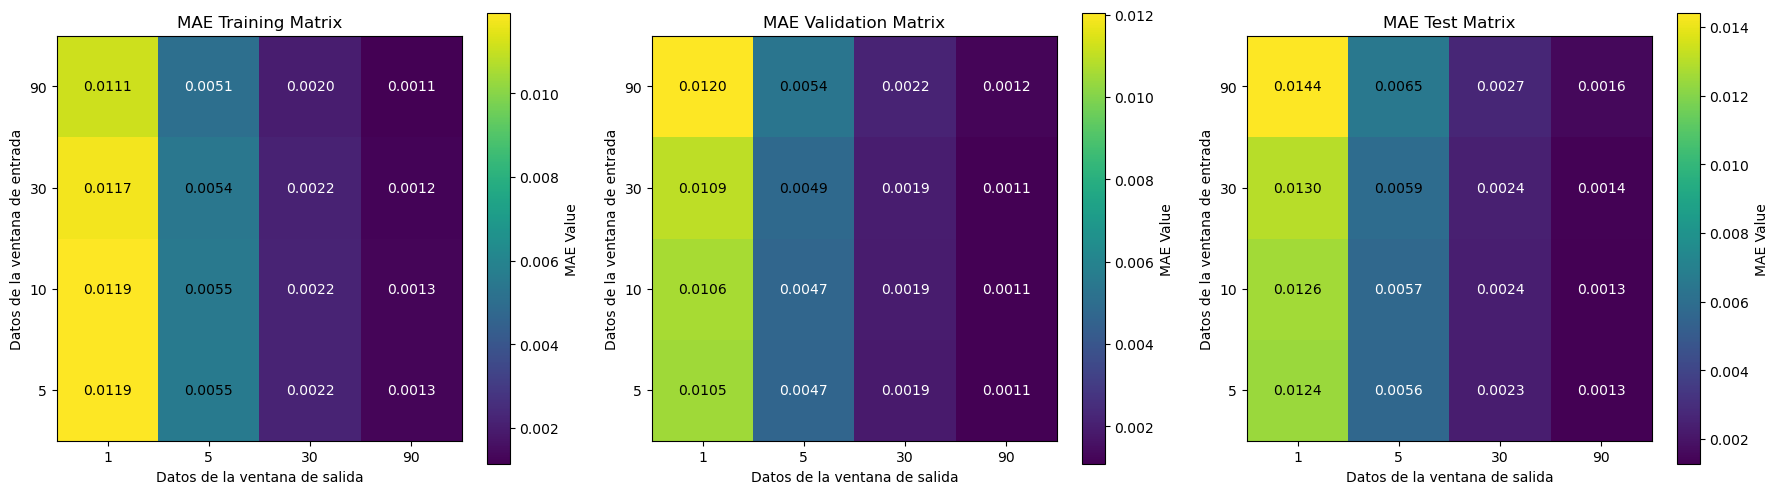

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

matrices = [mae_train_matrix, mae_val_matrix, mae_test_matrix]
titles = ['MAE Training Matrix', 'MAE Validation Matrix', 'MAE Test Matrix']

for i, ax in enumerate(axes):
    im = ax.imshow(matrices[i], cmap='viridis', origin='lower')
    
    ax.set_xlabel('Datos de la ventana de salida')
    ax.set_ylabel('Datos de la ventana de entrada')
    ax.set_title(titles[i])
    
    ax.set_xticks(np.arange(len(ventanas_salida)))
    ax.set_xticklabels(ventanas_salida)
    
    ax.set_yticks(np.arange(len(ventanas_entrada)))
    ax.set_yticklabels(ventanas_entrada)

    for y in range(matrices[i].shape[0]):
        for x in range(matrices[i].shape[1]):
            value = matrices[i][y, x]
            ax.text(x, y, f"{value:.4f}",
                    ha='center', va='center',
                    color='black' if value > np.mean(matrices[i]) else 'white')
    
    fig.colorbar(im, ax=ax, label='MAE Value')

plt.tight_layout()
plt.show()

## 3. Entrenamiento de modelos de Deep Learning

In [12]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.layers import LSTM, GRU
from tensorflow.keras.layers import MaxPooling1D, Convolution1D, GlobalAveragePooling1D
from tensorflow.keras.layers import Dropout, Activation, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from keras import regularizers

### 3.1 Modelos de capas densas (NN)

En el caso de las capas densas hay que interpretar los vectores de entrada (de longitud 5, 10, 30 y 90) como si fueran variables.

El procedimiento para todos los casos de modelos de capas densas que se entrenen, en función de la tupla (ventana entrada, ventana salida), es la siguiente:

- **Establecimiento de la arquitectura del modelo**
- **Entrenamiento del modelo:** Se han entrenado múltiples modelos y se ha ido perfilando la arquitectura hasta obtener el modelo definitivo priorizando la forma de las curvas de coste y el MAE.
- **Gráficos de las curvas de entrenamiento y validación**
- **Comparativa de resultados de la red neuronal densa con respecto al modelo baseline**: Para ello se obtienen las predicciones del modelo con los datos train, val y test en las escalas tranformadas. Se revierte la transforción de escalas con la función `inverse_transform` para que sea comparable con el baseline.

#### 3.1.1 Modelos con 5 datos de entrada

En el caso de los modelos con 5 datos de entrada podemos ver que las curvas converjen pero en cuanto a MAE no mejoran al baseline.

##### 3.1.1.1. Modelo con 1 dato de salida

In [13]:
train_data_5_1, train_target_5_1 = dicc_data_train_norm[(5,1)], dicc_target_train_norm[(5,1)]
val_data_5_1, val_target_5_1 = dicc_data_val_norm[(5,1)], dicc_target_val_norm[(5,1)]
test_data_5_1, test_target_5_1 = dicc_data_test_norm[(5,1)], dicc_target_test_norm[(5,1)]

In [14]:
num_samples_train_5_1 = train_data_5_1.shape[0]
num_samples_val_5_1 = val_data_5_1.shape[0]
num_samples_test_5_1 = test_data_5_1.shape[0]

# Flatten X_train_seq to (num_samples, input_window_size * num_features)
X_train_flat_5_1 = train_data_5_1.reshape(num_samples_train_5_1, -1)

# Flatten X_test_seq to (num_samples, input_window_size * num_features)
X_val_flat_5_1 = val_data_5_1.reshape(num_samples_val_5_1, -1)

# Flatten X_test_seq to (num_samples, input_window_size * num_features)
X_test_flat_5_1 = test_data_5_1.reshape(num_samples_test_5_1, -1)

In [62]:
# Modelo con 5 datos de entrada y uno de salida
model_NN_5_1 = Sequential()
model_NN_5_1.add(Dense(80, activation='relu', input_dim=(X_train_flat_5_1.shape[1])))
model_NN_5_1.add(Dropout(0.2))
model_NN_5_1.add(Dense(40, activation='relu', kernel_regularizer=regularizers.l2(0.003)))
#model_NN_5_1.add(Dense(64, activation='relu'))

#model_NN_5_1.add(Dropout(0.1))
# 3. Capa de salida para los 23 activos (sin escalar, valores reales de retornos)
model_NN_5_1.add(Dense(train_target_5_1.shape[1], activation='linear'))

# DEFINICIÓN DE FUNCIÓN DE COSTE Y OPTIMIZADOR
model_NN_5_1.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

c:\Users\mateo\anaconda31\envs\trading\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_NN_5_1 = model_NN_5_1.fit(X_train_flat_5_1, train_target_5_1, validation_data=(X_val_flat_5_1, val_target_5_1), epochs=1000, batch_size=128)

Epoch 1/1000


86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.8759 - val_loss: 0.7134
Epoch 2/1000
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.7761 - val_loss: 0.6624
Epoch 3/1000
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.7351 - val_loss: 0.6358
Epoch 4/1000
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.7150 - val_loss: 0.6233
Epoch 5/1000
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.7058 - val_loss: 0.6177
Epoch 6/1000
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.7017 - val_loss: 0.6153
Epoch 7/1000
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.6999 - val_loss: 0.6144
Epoch 8/1000
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.6992 - val_loss: 0.6139
Epoch 9/1000
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.6988 - val_loss: 0.6138
Epoch 10/1000
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.6985 - val_loss: 0.6137
Epoch 11/1000
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.6983 - val_loss: 0.6139
Epoch 12/1000
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.69

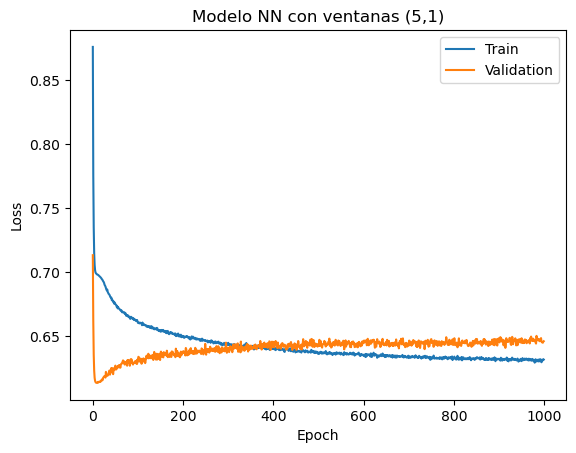

In [64]:
plt.plot(hist_NN_5_1.history['loss'])
plt.plot(hist_NN_5_1.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.title('Modelo NN con ventanas (5,1)')
plt.show()

In [65]:
# 1. El modelo predice en escala normalizada usando los datos de test
y_pred_nn_scaled_train_5_1 = model_NN_5_1.predict(X_train_flat_5_1)
y_pred_nn_scaled_val_5_1 = model_NN_5_1.predict(X_val_flat_5_1)
y_pred_nn_scaled_test_5_1 = model_NN_5_1.predict(X_test_flat_5_1)

# 2. Deshacemos la normalización usando el scaler de la llave (5,1)
scaler_y_5_1 = dicc_scaler[(5,1)]
y_pred_nn_real_train_5_1 = scaler_y_5_1.inverse_transform(y_pred_nn_scaled_train_5_1)
y_pred_nn_real_val_5_1 = scaler_y_5_1.inverse_transform(y_pred_nn_scaled_val_5_1)
y_pred_nn_real_test_5_1 = scaler_y_5_1.inverse_transform(y_pred_nn_scaled_test_5_1)

# 3. Comparamos las predicciones reales contra los datos originales sin normalizar
mae_nn_train_5_1 = mean_absolute_error(dicc_target_train_reg[(5,1)], y_pred_nn_real_train_5_1)
mae_nn_val_5_1 = mean_absolute_error(dicc_target_val[(5,1)], y_pred_nn_real_val_5_1)
mae_nn_test_5_1 = mean_absolute_error(dicc_target_test[(5,1)], y_pred_nn_real_test_5_1)

# 4. Comparamos manzanas con manzanas
print()
print('=======   Resultados modelo NN (5,1)   =======')
print()
print(f"MAE de la Regresión Lineal (train): {mae_reg_train[(5,1)]:.6f}")
print(f"MAE de la Red Neuronal (train):     {mae_nn_train_5_1:.6f}")
print()
print(f"MAE de la Regresión Lineal (val): {mae_reg_val[(5,1)]:.6f}")
print(f"MAE de la Red Neuronal (val):     {mae_nn_val_5_1:.6f}")
print()
print(f"MAE de la Regresión Lineal (test): {mae_reg_test[(5,1)]:.6f}")
print(f"MAE de la Red Neuronal (test):     {mae_nn_test_5_1:.6f}")
print()

342/342 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

=======   Resultados modelo NN (5,1)   =======

MAE de la Regresión Lineal (train): 0.011929
MAE de la Red Neuronal (train):     0.010437

MAE de la Regresión Lineal (val): 0.010497
MAE de la Red Neuronal (val):     0.010876

MAE de la Regresión Lineal (test): 0.012439
MAE de la Red Neuronal (test):     0.012947



##### 3.1.1.2. Modelo con 5 datos de salida

In [67]:
train_data_5_5, train_target_5_5 = dicc_data_train_norm[(5,5)], dicc_target_train_norm[(5,5)]
val_data_5_5, val_target_5_5 = dicc_data_val_norm[(5,5)], dicc_target_val_norm[(5,5)]
test_data_5_5, test_target_5_5 = dicc_data_test_norm[(5,5)], dicc_target_test_norm[(5,5)]

In [68]:
num_samples_train_5_5 = train_data_5_5.shape[0]
num_samples_val_5_5 = val_data_5_5.shape[0]
num_samples_test_5_5 = test_data_5_5.shape[0]

# Flatten X_train_seq to (num_samples, input_window_size * num_features)
X_train_flat_5_5 = train_data_5_5.reshape(num_samples_train_5_5, -1)

# Flatten X_test_seq to (num_samples, input_window_size * num_features)
X_val_flat_5_5 = val_data_5_5.reshape(num_samples_val_5_5, -1)

# Flatten X_test_seq to (num_samples, input_window_size * num_features)
X_test_flat_5_5 = test_data_5_5.reshape(num_samples_test_5_5, -1)

In [69]:
# Modelo con 5 datos de entrada y uno de salida
model_NN_5_5 = Sequential()
model_NN_5_5.add(Dense(80, activation='relu', input_dim=(X_train_flat_5_5.shape[1])))
model_NN_5_5.add(Dropout(0.2))
model_NN_5_5.add(Dense(40, activation='relu', kernel_regularizer=regularizers.l2(0.003)))
#model_NN_5_5.add(Dense(64, activation='relu'))

#model_NN_5_5.add(Dropout(0.1))
# 3. Capa de salida para los 23 activos (sin escalar, valores reales de retornos)
model_NN_5_5.add(Dense(train_target_5_5.shape[1], activation='linear'))

# DEFINICIÓN DE FUNCIÓN DE COSTE Y OPTIMIZADOR
model_NN_5_5.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

c:\Users\mateo\anaconda31\envs\trading\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [74]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_NN_5_5 = model_NN_5_5.fit(X_train_flat_5_5, train_target_5_5, validation_data=(X_val_flat_5_5, val_target_5_5), epochs=500)

Epoch 1/500
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6409 - val_loss: 0.6492
Epoch 2/500
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6403 - val_loss: 0.6500
Epoch 3/500
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.6400 - val_loss: 0.6526
Epoch 4/500
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.6396 - val_loss: 0.6520
Epoch 5/500
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.6399 - val_loss: 0.6512
Epoch 6/500
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6418 - val_loss: 0.6533
Epoch 7/500
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6389 - val_loss: 0.6532
Epoch 8/500
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6398 - val_loss: 0.6490
Epoch 9/500
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.6413 - val_loss: 0.6495
Epoch 10/500
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.6397 - val_loss: 0.6578
Epoch 11/500
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6416 - val_loss: 0.6503
Epoch 12/500
342/342 ━━━━━━━━━━━━━━━━━━━━

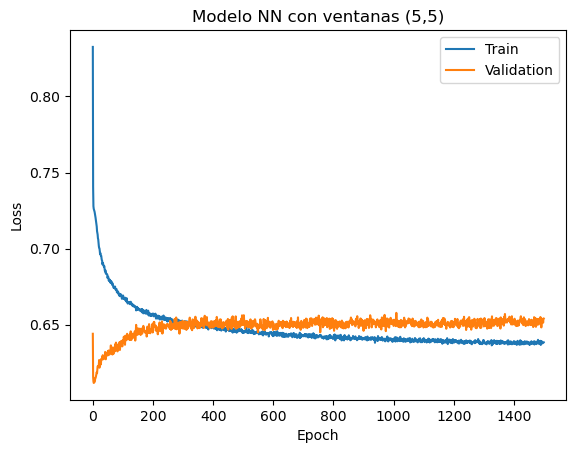

In [ ]:
plt.plot(hist_NN_5_5.history['loss'])
plt.plot(hist_NN_5_5.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.title('Modelo NN con ventanas (5,5)')
plt.show()

In [77]:
# 1. El modelo predice en escala normalizada usando los datos de test
y_pred_nn_scaled_train_5_5 = model_NN_5_5.predict(X_train_flat_5_5)
y_pred_nn_scaled_val_5_5 = model_NN_5_5.predict(X_val_flat_5_5)
y_pred_nn_scaled_test_5_5 = model_NN_5_5.predict(X_test_flat_5_5)

# 2. Deshacemos la normalización usando el scaler de la llave (5,5)
scaler_y_5_5 = dicc_scaler[(5,5)]
y_pred_nn_real_train_5_5 = scaler_y_5_5.inverse_transform(y_pred_nn_scaled_train_5_5)
y_pred_nn_real_val_5_5 = scaler_y_5_5.inverse_transform(y_pred_nn_scaled_val_5_5)
y_pred_nn_real_test_5_5 = scaler_y_5_5.inverse_transform(y_pred_nn_scaled_test_5_5)

# 3. Comparamos las predicciones reales contra los datos originales sin normalizar
mae_nn_train_5_5 = mean_absolute_error(dicc_target_train_reg[(5,5)], y_pred_nn_real_train_5_5)
mae_nn_val_5_5 = mean_absolute_error(dicc_target_val[(5,5)], y_pred_nn_real_val_5_5)
mae_nn_test_5_5 = mean_absolute_error(dicc_target_test[(5,5)], y_pred_nn_real_test_5_5)

# 4. Comparamos manzanas con manzanas
print()
print('=======   Resultados modelo NN (5,5)   =======')
print()
print(f"MAE de la Regresión Lineal (train): {mae_reg_train[(5,5)]:.6f}")
print(f"MAE de la Red Neuronal (train):     {mae_nn_train_5_5:.6f}")
print()
print(f"MAE de la Regresión Lineal (val): {mae_reg_val[(5,5)]:.6f}")
print(f"MAE de la Red Neuronal (val):     {mae_nn_val_5_5:.6f}")
print()
print(f"MAE de la Regresión Lineal (test): {mae_reg_test[(5,5)]:.6f}")
print(f"MAE de la Red Neuronal (test):     {mae_nn_test_5_5:.6f}")
print()

342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

=======   Resultados modelo NN (5,5)   =======

MAE de la Regresión Lineal (train): 0.005537
MAE de la Red Neuronal (train):     0.004696

MAE de la Regresión Lineal (val): 0.004675
MAE de la Red Neuronal (val):     0.004938

MAE de la Regresión Lineal (test): 0.005641
MAE de la Red Neuronal (test):     0.005903



##### 3.1.1.3. Modelo con 30 datos de salida

In [78]:
train_data_5_30, train_target_5_30 = dicc_data_train_norm[(5,30)], dicc_target_train_norm[(5,30)]
val_data_5_30, val_target_5_30 = dicc_data_val_norm[(5,30)], dicc_target_val_norm[(5,30)]
test_data_5_30, test_target_5_30 = dicc_data_test_norm[(5,30)], dicc_target_test_norm[(5,30)]

In [79]:
num_samples_train_5_30 = train_data_5_30.shape[0]
num_samples_val_5_30 = val_data_5_30.shape[0]
num_samples_test_5_30 = test_data_5_30.shape[0]

# Flatten X_train_seq to (num_samples, input_window_size * num_features)
X_train_flat_5_30 = train_data_5_30.reshape(num_samples_train_5_30, -1)

# Flatten X_test_seq to (num_samples, input_window_size * num_features)
X_val_flat_5_30 = val_data_5_30.reshape(num_samples_val_5_30, -1)

# Flatten X_test_seq to (num_samples, input_window_size * num_features)
X_test_flat_5_30 = test_data_5_30.reshape(num_samples_test_5_30, -1)

In [84]:
# Modelo con 5 datos de entrada y uno de salida
model_NN_5_30 = Sequential()
model_NN_5_30.add(Dense(80, activation='relu', input_dim=(X_train_flat_5_30.shape[1])))
model_NN_5_30.add(Dropout(0.4))
model_NN_5_30.add(Dense(40, activation='relu', kernel_regularizer=regularizers.l2(0.005)))
#model_NN_5_30.add(Dense(64, activation='relu'))

#model_NN_5_30.add(Dropout(0.1))
# 3. Capa de salida para los 23 activos (sin escalar, valores reales de retornos)
model_NN_5_30.add(Dense(train_target_5_30.shape[1], activation='linear'))

# DEFINICIÓN DE FUNCIÓN DE COSTE Y OPTIMIZADOR
model_NN_5_30.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

c:\Users\mateo\anaconda31\envs\trading\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [89]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_NN_5_30 = model_NN_5_30.fit(X_train_flat_5_30, train_target_5_30, validation_data=(X_val_flat_5_30, val_target_5_30), epochs=500)

Epoch 1/500
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.6742 - val_loss: 0.6823
Epoch 2/500
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.6741 - val_loss: 0.6825
Epoch 3/500
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.6746 - val_loss: 0.6817
Epoch 4/500
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6748 - val_loss: 0.6834
Epoch 5/500
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6744 - val_loss: 0.6812
Epoch 6/500
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.6732 - val_loss: 0.6815
Epoch 7/500
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.6751 - val_loss: 0.6795
Epoch 8/500
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.6741 - val_loss: 0.6826
Epoch 9/500
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.6741 - val_loss: 0.6818
Epoch 10/500
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6745 - val_loss: 0.6825
Epoch 11/500
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6737 - val_loss: 0.6799
Epoch 12/500
341/341 ━━━━━━━━━━━━━━━━━━━━

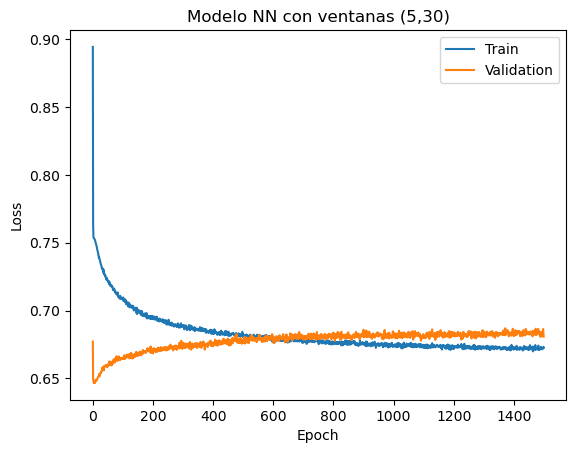

In [ ]:
plt.plot(hist_NN_5_30.history['loss'])
plt.plot(hist_NN_5_30.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.title('Modelo NN con ventanas (5,30)')
plt.show()

In [91]:
# 1. El modelo predice en escala normalizada usando los datos de test
y_pred_nn_scaled_train_5_30 = model_NN_5_30.predict(X_train_flat_5_30)
y_pred_nn_scaled_val_5_30 = model_NN_5_30.predict(X_val_flat_5_30)
y_pred_nn_scaled_test_5_30 = model_NN_5_30.predict(X_test_flat_5_30)

# 2. Deshacemos la normalización usando el scaler de la llave (5,30)
scaler_y_5_30 = dicc_scaler[(5,30)]
y_pred_nn_real_train_5_30 = scaler_y_5_30.inverse_transform(y_pred_nn_scaled_train_5_30)
y_pred_nn_real_val_5_30 = scaler_y_5_30.inverse_transform(y_pred_nn_scaled_val_5_30)
y_pred_nn_real_test_5_30 = scaler_y_5_30.inverse_transform(y_pred_nn_scaled_test_5_30)

# 3. Comparamos las predicciones reales contra los datos originales sin normalizar
mae_nn_train_5_30 = mean_absolute_error(dicc_target_train_reg[(5,30)], y_pred_nn_real_train_5_30)
mae_nn_val_5_30 = mean_absolute_error(dicc_target_val[(5,30)], y_pred_nn_real_val_5_30)
mae_nn_test_5_30 = mean_absolute_error(dicc_target_test[(5,30)], y_pred_nn_real_test_5_30)

# 4. Comparamos manzanas con manzanas
print()
print('=======   Resultados modelo NN (5,30)   =======')
print()
print(f"MAE de la Regresión Lineal (train): {mae_reg_train[(5,30)]:.6f}")
print(f"MAE de la Red Neuronal (train):     {mae_nn_train_5_30:.6f}")
print()
print(f"MAE de la Regresión Lineal (val): {mae_reg_val[(5,30)]:.6f}")
print(f"MAE de la Red Neuronal (val):     {mae_nn_val_5_30:.6f}")
print()
print(f"MAE de la Regresión Lineal (test): {mae_reg_test[(5,30)]:.6f}")
print(f"MAE de la Red Neuronal (test):     {mae_nn_test_5_30:.6f}")
print()

341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

=======   Resultados modelo NN (5,30)   =======

MAE de la Regresión Lineal (train): 0.002226
MAE de la Red Neuronal (train):     0.001921

MAE de la Regresión Lineal (val): 0.001901
MAE de la Red Neuronal (val):     0.001985

MAE de la Regresión Lineal (test): 0.002342
MAE de la Red Neuronal (test):     0.002415



##### 3.1.1.4. Modelo con 90 datos de salida

In [92]:
train_data_5_90, train_target_5_90 = dicc_data_train_norm[(5,90)], dicc_target_train_norm[(5,90)]
val_data_5_90, val_target_5_90 = dicc_data_val_norm[(5,90)], dicc_target_val_norm[(5,90)]
test_data_5_90, test_target_5_90 = dicc_data_test_norm[(5,90)], dicc_target_test_norm[(5,90)]

In [93]:
num_samples_train_5_90 = train_data_5_90.shape[0]
num_samples_val_5_90 = val_data_5_90.shape[0]
num_samples_test_5_90 = test_data_5_90.shape[0]

# Flatten X_train_seq to (num_samples, input_window_size * num_features)
X_train_flat_5_90 = train_data_5_90.reshape(num_samples_train_5_90, -1)

# Flatten X_test_seq to (num_samples, input_window_size * num_features)
X_val_flat_5_90 = val_data_5_90.reshape(num_samples_val_5_90, -1)

# Flatten X_test_seq to (num_samples, input_window_size * num_features)
X_test_flat_5_90 = test_data_5_90.reshape(num_samples_test_5_90, -1)

In [98]:
# Modelo con 5 datos de entrada y uno de salida
model_NN_5_90 = Sequential()
model_NN_5_90.add(Dense(80, activation='relu', input_dim=(X_train_flat_5_90.shape[1])))
model_NN_5_90.add(Dropout(0.4))
model_NN_5_90.add(Dense(40, activation='relu', kernel_regularizer=regularizers.l2(0.005)))
#model_NN_5_90.add(Dense(64, activation='relu'))

model_NN_5_90.add(Dropout(0.2))
# 3. Capa de salida para los 23 activos (sin escalar, valores reales de retornos)
model_NN_5_90.add(Dense(train_target_5_90.shape[1], activation='linear'))

# DEFINICIÓN DE FUNCIÓN DE COSTE Y OPTIMIZADOR
model_NN_5_90.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

c:\Users\mateo\anaconda31\envs\trading\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [99]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_NN_5_90 = model_NN_5_90.fit(X_train_flat_5_90, train_target_5_90, validation_data=(X_val_flat_5_90, val_target_5_90), epochs=1000)

Epoch 1/1000


340/340 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.9219 - val_loss: 0.6984
Epoch 2/1000
340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7767 - val_loss: 0.6644
Epoch 3/1000
340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7633 - val_loss: 0.6618
Epoch 4/1000
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.7621 - val_loss: 0.6620
Epoch 5/1000
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.7617 - val_loss: 0.6629
Epoch 6/1000
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.7610 - val_loss: 0.6636
Epoch 7/1000
340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7607 - val_loss: 0.6640
Epoch 8/1000
340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7594 - val_loss: 0.6647
Epoch 9/1000
340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7586 - val_loss: 0.6661
Epoch 10/1000
340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7577 - val_loss: 0.6670
Epoch 11/1000
340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7565 - val_loss: 0.6691
Epoch 12/1000
340/340 ━━━━━━━━━━━━━━━━━━━━ 

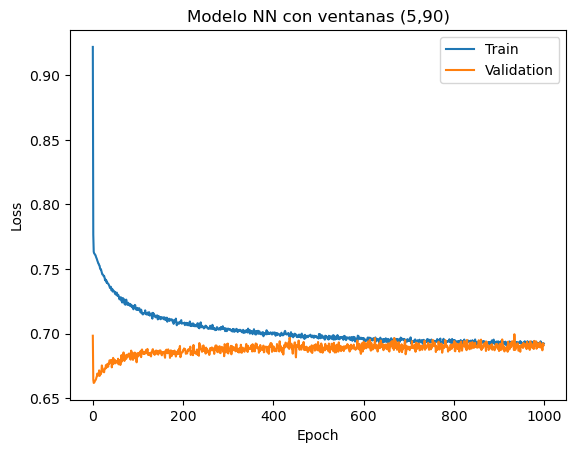

In [100]:
plt.plot(hist_NN_5_90.history['loss'])
plt.plot(hist_NN_5_90.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.title('Modelo NN con ventanas (5,90)')
plt.show()

In [102]:
# 1. El modelo predice en escala normalizada usando los datos de test
y_pred_nn_scaled_train_5_90 = model_NN_5_90.predict(X_train_flat_5_90)
y_pred_nn_scaled_val_5_90 = model_NN_5_90.predict(X_val_flat_5_90)
y_pred_nn_scaled_test_5_90 = model_NN_5_90.predict(X_test_flat_5_90)

# 2. Deshacemos la normalización usando el scaler de la llave (5,90)
scaler_y_5_90 = dicc_scaler[(5,90)]
y_pred_nn_real_train_5_90 = scaler_y_5_90.inverse_transform(y_pred_nn_scaled_train_5_90)
y_pred_nn_real_val_5_90 = scaler_y_5_90.inverse_transform(y_pred_nn_scaled_val_5_90)
y_pred_nn_real_test_5_90 = scaler_y_5_90.inverse_transform(y_pred_nn_scaled_test_5_90)

# 3. Comparamos las predicciones reales contra los datos originales sin normalizar
mae_nn_train_5_90 = mean_absolute_error(dicc_target_train_reg[(5,90)], y_pred_nn_real_train_5_90)
mae_nn_val_5_90 = mean_absolute_error(dicc_target_val[(5,90)], y_pred_nn_real_val_5_90)
mae_nn_test_5_90 = mean_absolute_error(dicc_target_test[(5,90)], y_pred_nn_real_test_5_90)

# 4. Comparamos manzanas con manzanas
print()
print('=======   Resultados modelo NN (5,90)   =======')
print()
print(f"MAE de la Regresión Lineal (train): {mae_reg_train[(5,90)]:.6f}")
print(f"MAE de la Red Neuronal (train):     {mae_nn_train_5_90:.6f}")
print()
print(f"MAE de la Regresión Lineal (val): {mae_reg_val[(5,90)]:.6f}")
print(f"MAE de la Red Neuronal (val):     {mae_nn_val_5_90:.6f}")
print()
print(f"MAE de la Regresión Lineal (test): {mae_reg_test[(5,90)]:.6f}")
print(f"MAE de la Red Neuronal (test):     {mae_nn_test_5_90:.6f}")
print()

340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

=======   Resultados modelo NN (5,90)   =======

MAE de la Regresión Lineal (train): 0.001277
MAE de la Red Neuronal (train):     0.001107

MAE de la Regresión Lineal (val): 0.001090
MAE de la Red Neuronal (val):     0.001127

MAE de la Regresión Lineal (test): 0.001275
MAE de la Red Neuronal (test):     0.001305



#### 3.1.2 Modelos con 10 datos de entrada

En el caso de los modelos con vectores de longitud 10, las curvas acaban converjiendo pero no mejoran al baseline.

##### 3.1.2.1. Modelo con 1 dato de salida

In [117]:
train_data_10_1, train_target_10_1 = dicc_data_train_norm[(10,1)], dicc_target_train_norm[(10,1)]
val_data_10_1, val_target_10_1 = dicc_data_val_norm[(10,1)], dicc_target_val_norm[(10,1)]
test_data_10_1, test_target_10_1 = dicc_data_test_norm[(10,1)], dicc_target_test_norm[(10,1)]

In [118]:
num_samples_train_10_1 = train_data_10_1.shape[0]
num_samples_val_10_1 = val_data_10_1.shape[0]
num_samples_test_10_1 = test_data_10_1.shape[0]

# Flatten X_train_seq to (num_samples, input_window_size * num_features)
X_train_flat_10_1 = train_data_10_1.reshape(num_samples_train_10_1, -1)

# Flatten X_test_seq to (num_samples, input_window_size * num_features)
X_val_flat_10_1 = val_data_10_1.reshape(num_samples_val_10_1, -1)

# Flatten X_test_seq to (num_samples, input_window_size * num_features)
X_test_flat_10_1 = test_data_10_1.reshape(num_samples_test_10_1, -1)

In [134]:
# Modelo con 5 datos de entrada y uno de salida
model_NN_10_1 = Sequential()
model_NN_10_1.add(Dense(80, activation='relu', input_dim=(X_train_flat_10_1.shape[1])))
model_NN_10_1.add(Dropout(0.4))
model_NN_10_1.add(Dense(40, kernel_regularizer=regularizers.l2(0.001)))
#model_NN_10_1.add(Dense(64, activation='relu'))
model_NN_10_1.add(Dropout(0.2))

# 3. Capa de salida para los 23 activos (sin escalar, valores reales de retornos)
model_NN_10_1.add(Dense(train_target_10_1.shape[1], activation='linear'))

# DEFINICIÓN DE FUNCIÓN DE COSTE Y OPTIMIZADOR
model_NN_10_1.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

c:\Users\mateo\anaconda31\envs\trading\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [135]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_NN_10_1 = model_NN_10_1.fit(X_train_flat_10_1, train_target_10_1, validation_data=(X_val_flat_10_1, val_target_10_1), epochs=1000)

Epoch 1/1000
342/342 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - loss: 0.8918 - val_loss: 0.6458
Epoch 2/1000
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.7375 - val_loss: 0.6318
Epoch 3/1000
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7184 - val_loss: 0.6255
Epoch 4/1000
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.7092 - val_loss: 0.6222
Epoch 5/1000
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.7033 - val_loss: 0.6192
Epoch 6/1000
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.6996 - val_loss: 0.6185
Epoch 7/1000
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6976 - val_loss: 0.6176
Epoch 8/1000
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.6945 - val_loss: 0.6196
Epoch 9/1000
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6942 - val_loss: 0.6187
Epoch 10/1000
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.6910 - val_loss: 0.6201
Epoch 11/1000
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.6894 - val_loss: 0.6213
Epoch 12/1000
342/342 ━━━━━━━

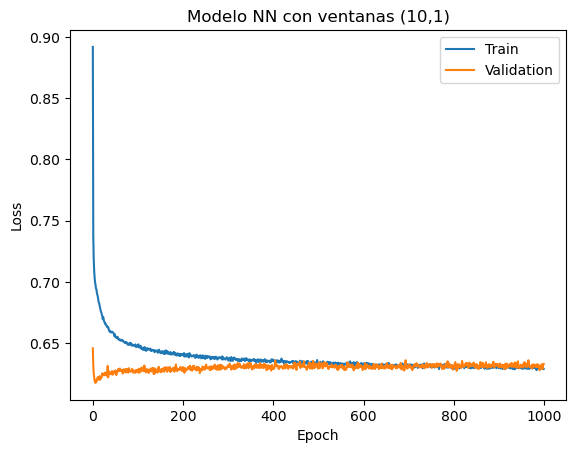

In [136]:
plt.plot(hist_NN_10_1.history['loss'])
plt.plot(hist_NN_10_1.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.title('Modelo NN con ventanas (10,1)')
plt.show()

In [137]:
# 1. El modelo predice en escala normalizada usando los datos de test
y_pred_nn_scaled_train_10_1 = model_NN_10_1.predict(X_train_flat_10_1)
y_pred_nn_scaled_val_10_1 = model_NN_10_1.predict(X_val_flat_10_1)
y_pred_nn_scaled_test_10_1 = model_NN_10_1.predict(X_test_flat_10_1)

# 2. Deshacemos la normalización usando el scaler de la llave (10,1)
scaler_y_10_1 = dicc_scaler[(10,1)]
y_pred_nn_real_train_10_1 = scaler_y_10_1.inverse_transform(y_pred_nn_scaled_train_10_1)
y_pred_nn_real_val_10_1 = scaler_y_10_1.inverse_transform(y_pred_nn_scaled_val_10_1)
y_pred_nn_real_test_10_1 = scaler_y_10_1.inverse_transform(y_pred_nn_scaled_test_10_1)

# 3. Comparamos las predicciones reales contra los datos originales sin normalizar
mae_nn_train_10_1 = mean_absolute_error(dicc_target_train_reg[(10,1)], y_pred_nn_real_train_10_1)
mae_nn_val_10_1 = mean_absolute_error(dicc_target_val[(10,1)], y_pred_nn_real_val_10_1)
mae_nn_test_10_1 = mean_absolute_error(dicc_target_test[(10,1)], y_pred_nn_real_test_10_1)

# 4. Comparamos manzanas con manzanas
print()
print('=======   Resultados modelo NN (10,1)   =======')
print()
print(f"MAE de la Regresión Lineal (train): {mae_reg_train[(10,1)]:.6f}")
print(f"MAE de la Red Neuronal (train):     {mae_nn_train_10_1:.6f}")
print()
print(f"MAE de la Regresión Lineal (val): {mae_reg_val[(10,1)]:.6f}")
print(f"MAE de la Red Neuronal (val):     {mae_nn_val_10_1:.6f}")
print()
print(f"MAE de la Regresión Lineal (test): {mae_reg_test[(10,1)]:.6f}")
print(f"MAE de la Red Neuronal (test):     {mae_nn_test_10_1:.6f}")
print()

342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

=======   Resultados modelo NN (10,1)   =======

MAE de la Regresión Lineal (train): 0.011893
MAE de la Red Neuronal (train):     0.010264

MAE de la Regresión Lineal (val): 0.010598
MAE de la Red Neuronal (val):     0.010652

MAE de la Regresión Lineal (test): 0.012597
MAE de la Red Neuronal (test):     0.013104



##### 3.1.2.2. Modelo con 5 datos de salida

In [109]:
train_data_10_5, train_target_10_5 = dicc_data_train_norm[(10,5)], dicc_target_train_norm[(10,5)]
val_data_10_5, val_target_10_5 = dicc_data_val_norm[(10,5)], dicc_target_val_norm[(10,5)]
test_data_10_5, test_target_10_5 = dicc_data_test_norm[(10,5)], dicc_target_test_norm[(10,5)]

In [110]:
num_samples_train_10_5 = train_data_10_5.shape[0]
num_samples_val_10_5 = val_data_10_5.shape[0]
num_samples_test_10_5 = test_data_10_5.shape[0]

# Flatten X_train_seq to (num_samples, input_window_size * num_features)
X_train_flat_10_5 = train_data_10_5.reshape(num_samples_train_10_5, -1)

# Flatten X_test_seq to (num_samples, input_window_size * num_features)
X_val_flat_10_5 = val_data_10_5.reshape(num_samples_val_10_5, -1)

# Flatten X_test_seq to (num_samples, input_window_size * num_features)
X_test_flat_10_5 = test_data_10_5.reshape(num_samples_test_10_5, -1)

In [156]:
# Modelo con 5 datos de entrada y uno de salida
model_NN_10_5 = Sequential()
model_NN_10_5.add(Dense(80, activation='relu', input_dim=(X_train_flat_10_5.shape[1])))
model_NN_10_5.add(Dropout(0.3))
model_NN_10_5.add(Dense(40, kernel_regularizer=regularizers.l2(0.001)))
#model_NN_10_5.add(Dense(64, activation='relu'))
#model_NN_10_5.add(Dropout(0.2))

# 3. Capa de salida para los 23 activos (sin escalar, valores reales de retornos)
model_NN_10_5.add(Dense(train_target_10_5.shape[1], activation='linear'))

# DEFINICIÓN DE FUNCIÓN DE COSTE Y OPTIMIZADOR
model_NN_10_5.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

c:\Users\mateo\anaconda31\envs\trading\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [157]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_NN_10_5 = model_NN_10_5.fit(X_train_flat_10_5, train_target_10_5, validation_data=(X_val_flat_10_5, val_target_10_5), epochs=500)

Epoch 1/500


342/342 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.8525 - val_loss: 0.6462
Epoch 2/500
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.7537 - val_loss: 0.6338
Epoch 3/500
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.7417 - val_loss: 0.6272
Epoch 4/500
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.7335 - val_loss: 0.6245
Epoch 5/500
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7277 - val_loss: 0.6211
Epoch 6/500
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7223 - val_loss: 0.6225
Epoch 7/500
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7172 - val_loss: 0.6196
Epoch 8/500
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7135 - val_loss: 0.6197
Epoch 9/500
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7097 - val_loss: 0.6197
Epoch 10/500
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7055 - val_loss: 0.6209
Epoch 11/500
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7013 - val_loss: 0.6225
Epoch 12/500
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

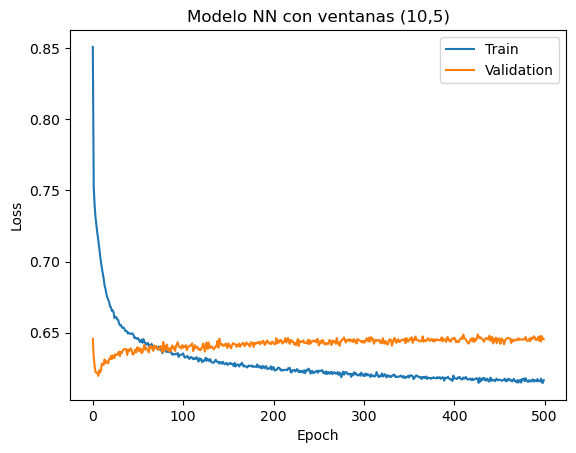

In [154]:
plt.plot(hist_NN_10_5.history['loss'])
plt.plot(hist_NN_10_5.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.title('Modelo NN con ventanas (10,5)')
plt.show()

In [155]:
# 1. El modelo predice en escala normalizada usando los datos de test
y_pred_nn_scaled_train_10_5 = model_NN_10_5.predict(X_train_flat_10_5)
y_pred_nn_scaled_val_10_5 = model_NN_10_5.predict(X_val_flat_10_5)
y_pred_nn_scaled_test_10_5 = model_NN_10_5.predict(X_test_flat_10_5)

# 2. Deshacemos la normalización usando el scaler de la llave (10,5)
scaler_y_10_5 = dicc_scaler[(10,5)]
y_pred_nn_real_train_10_5 = scaler_y_10_5.inverse_transform(y_pred_nn_scaled_train_10_5)
y_pred_nn_real_val_10_5 = scaler_y_10_5.inverse_transform(y_pred_nn_scaled_val_10_5)
y_pred_nn_real_test_10_5 = scaler_y_10_5.inverse_transform(y_pred_nn_scaled_test_10_5)

# 3. Comparamos las predicciones reales contra los datos originales sin normalizar
mae_nn_train_10_5 = mean_absolute_error(dicc_target_train_reg[(10,5)], y_pred_nn_real_train_10_5)
mae_nn_val_10_5 = mean_absolute_error(dicc_target_val[(10,5)], y_pred_nn_real_val_10_5)
mae_nn_test_10_5 = mean_absolute_error(dicc_target_test[(10,5)], y_pred_nn_real_test_10_5)

# 4. Comparamos manzanas con manzanas
print()
print('=======   Resultados modelo NN (10,5)   =======')
print()
print(f"MAE de la Regresión Lineal (train): {mae_reg_train[(10,5)]:.6f}")
print(f"MAE de la Red Neuronal (train):     {mae_nn_train_10_5:.6f}")
print()
print(f"MAE de la Regresión Lineal (val): {mae_reg_val[(10,5)]:.6f}")
print(f"MAE de la Red Neuronal (val):     {mae_nn_val_10_5:.6f}")
print()
print(f"MAE de la Regresión Lineal (test): {mae_reg_test[(10,5)]:.6f}")
print(f"MAE de la Red Neuronal (test):     {mae_nn_test_10_5:.6f}")
print()

342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

=======   Resultados modelo NN (10,5)   =======

MAE de la Regresión Lineal (train): 0.005508
MAE de la Red Neuronal (train):     0.004511

MAE de la Regresión Lineal (val): 0.004713
MAE de la Red Neuronal (val):     0.004885

MAE de la Regresión Lineal (test): 0.005716
MAE de la Red Neuronal (test):     0.006019



##### 3.1.2.3. Modelo con 30 datos de salida

In [158]:
train_data_10_30, train_target_10_30 = dicc_data_train_norm[(10,30)], dicc_target_train_norm[(10,30)]
val_data_10_30, val_target_10_30 = dicc_data_val_norm[(10,30)], dicc_target_val_norm[(10,30)]
test_data_10_30, test_target_10_30 = dicc_data_test_norm[(10,30)], dicc_target_test_norm[(10,30)]

In [159]:
num_samples_train_10_30 = train_data_10_30.shape[0]
num_samples_val_10_30 = val_data_10_30.shape[0]
num_samples_test_10_30 = test_data_10_30.shape[0]

# Flatten X_train_seq to (num_samples, input_window_size * num_features)
X_train_flat_10_30 = train_data_10_30.reshape(num_samples_train_10_30, -1)

# Flatten X_test_seq to (num_samples, input_window_size * num_features)
X_val_flat_10_30 = val_data_10_30.reshape(num_samples_val_10_30, -1)

# Flatten X_test_seq to (num_samples, input_window_size * num_features)
X_test_flat_10_30 = test_data_10_30.reshape(num_samples_test_10_30, -1)

In [165]:
# Modelo con 5 datos de entrada y uno de salida
model_NN_10_30 = Sequential()
model_NN_10_30.add(Dense(80, activation='relu', input_dim=(X_train_flat_10_30.shape[1])))
model_NN_10_30.add(Dropout(0.4))
model_NN_10_30.add(Dense(40))#, kernel_regularizer=regularizers.l2(0.001)))
#model_NN_10_30.add(Dense(64, activation='relu'))
model_NN_10_30.add(Dropout(0.2))

# 3. Capa de salida para los 23 activos (sin escalar, valores reales de retornos)
model_NN_10_30.add(Dense(train_target_10_30.shape[1], activation='linear'))

# DEFINICIÓN DE FUNCIÓN DE COSTE Y OPTIMIZADOR
model_NN_10_30.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

c:\Users\mateo\anaconda31\envs\trading\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [166]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_NN_10_30 = model_NN_10_30.fit(X_train_flat_10_30, train_target_10_30, validation_data=(X_val_flat_10_30, val_target_10_30), epochs=500)

Epoch 1/500


341/341 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.8973 - val_loss: 0.6495
Epoch 2/500
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.7700 - val_loss: 0.6470
Epoch 3/500
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7586 - val_loss: 0.6464
Epoch 4/500
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.7542 - val_loss: 0.6467
Epoch 5/500
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7508 - val_loss: 0.6464
Epoch 6/500
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7476 - val_loss: 0.6470
Epoch 7/500
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7446 - val_loss: 0.6476
Epoch 8/500
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7423 - val_loss: 0.6484
Epoch 9/500
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.7390 - val_loss: 0.6484
Epoch 10/500
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.7368 - val_loss: 0.6489
Epoch 11/500
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.7335 - val_loss: 0.6490
Epoch 12/500
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

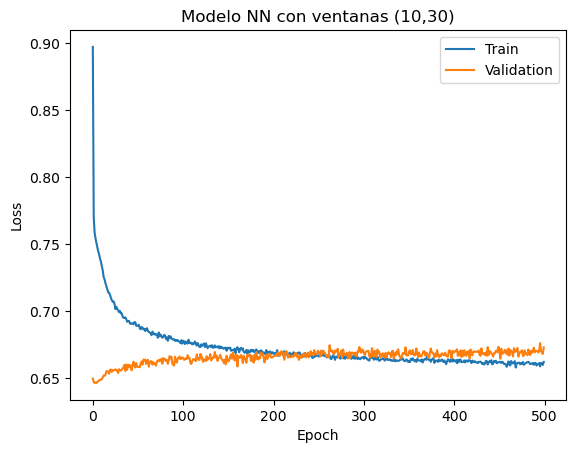

In [167]:
plt.plot(hist_NN_10_30.history['loss'])
plt.plot(hist_NN_10_30.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.title('Modelo NN con ventanas (10,30)')
plt.show()

In [168]:
# 1. El modelo predice en escala normalizada usando los datos de test
y_pred_nn_scaled_train_10_30 = model_NN_10_30.predict(X_train_flat_10_30)
y_pred_nn_scaled_val_10_30 = model_NN_10_30.predict(X_val_flat_10_30)
y_pred_nn_scaled_test_10_30 = model_NN_10_30.predict(X_test_flat_10_30)

# 2. Deshacemos la normalización usando el scaler de la llave (10,30)
scaler_y_10_30 = dicc_scaler[(10,30)]
y_pred_nn_real_train_10_30 = scaler_y_10_30.inverse_transform(y_pred_nn_scaled_train_10_30)
y_pred_nn_real_val_10_30 = scaler_y_10_30.inverse_transform(y_pred_nn_scaled_val_10_30)
y_pred_nn_real_test_10_30 = scaler_y_10_30.inverse_transform(y_pred_nn_scaled_test_10_30)

# 3. Comparamos las predicciones reales contra los datos originales sin normalizar
mae_nn_train_10_30 = mean_absolute_error(dicc_target_train_reg[(10,30)], y_pred_nn_real_train_10_30)
mae_nn_val_10_30 = mean_absolute_error(dicc_target_val[(10,30)], y_pred_nn_real_val_10_30)
mae_nn_test_10_30 = mean_absolute_error(dicc_target_test[(10,30)], y_pred_nn_real_test_10_30)

# 4. Comparamos manzanas con manzanas
print()
print('=======   Resultados modelo NN (10,30)   =======')
print()
print(f"MAE de la Regresión Lineal (train): {mae_reg_train[(10,30)]:.6f}")
print(f"MAE de la Red Neuronal (train):     {mae_nn_train_10_30:.6f}")
print()
print(f"MAE de la Regresión Lineal (val): {mae_reg_val[(10,30)]:.6f}")
print(f"MAE de la Red Neuronal (val):     {mae_nn_val_10_30:.6f}")
print()
print(f"MAE de la Regresión Lineal (test): {mae_reg_test[(10,30)]:.6f}")
print(f"MAE de la Red Neuronal (test):     {mae_nn_test_10_30:.6f}")
print()

341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

=======   Resultados modelo NN (10,30)   =======

MAE de la Regresión Lineal (train): 0.002213
MAE de la Red Neuronal (train):     0.001844

MAE de la Regresión Lineal (val): 0.001908
MAE de la Red Neuronal (val):     0.001970

MAE de la Regresión Lineal (test): 0.002362
MAE de la Red Neuronal (test):     0.002468



##### 3.1.2.4. Modelo con 90 datos de salida

In [13]:
train_data_10_90, train_target_10_90 = dicc_data_train_norm[(10,90)], dicc_target_train_norm[(10,90)]
val_data_10_90, val_target_10_90 = dicc_data_val_norm[(10,90)], dicc_target_val_norm[(10,90)]
test_data_10_90, test_target_10_90 = dicc_data_test_norm[(10,90)], dicc_target_test_norm[(10,90)]

In [14]:
num_samples_train_10_90 = train_data_10_90.shape[0]
num_samples_val_10_90 = val_data_10_90.shape[0]
num_samples_test_10_90 = test_data_10_90.shape[0]

# Flatten X_train_seq to (num_samples, input_window_size * num_features)
X_train_flat_10_90 = train_data_10_90.reshape(num_samples_train_10_90, -1)

# Flatten X_test_seq to (num_samples, input_window_size * num_features)
X_val_flat_10_90 = val_data_10_90.reshape(num_samples_val_10_90, -1)

# Flatten X_test_seq to (num_samples, input_window_size * num_features)
X_test_flat_10_90 = test_data_10_90.reshape(num_samples_test_10_90, -1)

In [15]:
# Modelo con 5 datos de entrada y uno de salida
model_NN_10_90 = Sequential()
model_NN_10_90.add(Dense(80, activation='relu', input_dim=(X_train_flat_10_90.shape[1])))
model_NN_10_90.add(Dropout(0.4))
model_NN_10_90.add(Dense(40, kernel_regularizer=regularizers.l2(0.001)))
#model_NN_10_90.add(Dense(64, activation='relu'))
model_NN_10_90.add(Dropout(0.2))

# 3. Capa de salida para los 23 activos (sin escalar, valores reales de retornos)
model_NN_10_90.add(Dense(train_target_10_90.shape[1], activation='linear'))

# DEFINICIÓN DE FUNCIÓN DE COSTE Y OPTIMIZADOR
model_NN_10_90.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

c:\Users\mateo\anaconda31\envs\trading\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_NN_10_90 = model_NN_10_90.fit(X_train_flat_10_90, train_target_10_90, validation_data=(X_val_flat_10_90, val_target_10_90), epochs=500)

Epoch 1/500
340/340 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.9437 - val_loss: 0.6902
Epoch 2/500
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.7966 - val_loss: 0.6786
Epoch 3/500
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.7779 - val_loss: 0.6739
Epoch 4/500
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.7685 - val_loss: 0.6723
Epoch 5/500
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.7626 - val_loss: 0.6712
Epoch 6/500
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.7576 - val_loss: 0.6723
Epoch 7/500
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.7536 - val_loss: 0.6727
Epoch 8/500
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.7504 - val_loss: 0.6729
Epoch 9/500
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.7473 - val_loss: 0.6764
Epoch 10/500
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.7442 - val_loss: 0.6792
Epoch 11/500
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.7422 - val_loss: 0.6757
Epoch 12/500
340/340 ━━━━━━━━━━━━━━━━━━━━

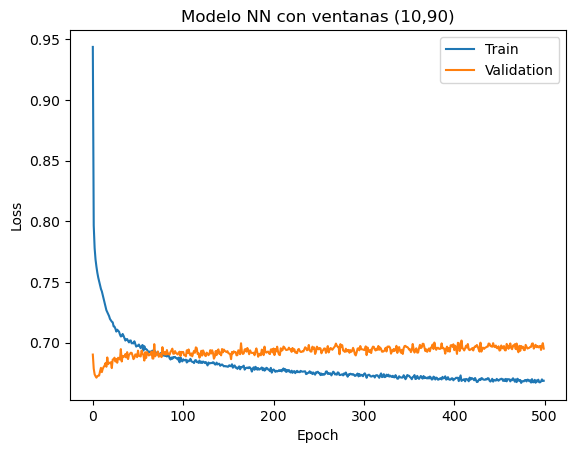

In [17]:
plt.plot(hist_NN_10_90.history['loss'])
plt.plot(hist_NN_10_90.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.title('Modelo NN con ventanas (10,90)')
plt.show()

In [18]:
# 1. El modelo predice en escala normalizada usando los datos de test
y_pred_nn_scaled_train_10_90 = model_NN_10_90.predict(X_train_flat_10_90)
y_pred_nn_scaled_val_10_90 = model_NN_10_90.predict(X_val_flat_10_90)
y_pred_nn_scaled_test_10_90 = model_NN_10_90.predict(X_test_flat_10_90)

# 2. Deshacemos la normalización usando el scaler de la llave (10,90)
scaler_y_10_90 = dicc_scaler[(10,90)]
y_pred_nn_real_train_10_90 = scaler_y_10_90.inverse_transform(y_pred_nn_scaled_train_10_90)
y_pred_nn_real_val_10_90 = scaler_y_10_90.inverse_transform(y_pred_nn_scaled_val_10_90)
y_pred_nn_real_test_10_90 = scaler_y_10_90.inverse_transform(y_pred_nn_scaled_test_10_90)

# 3. Comparamos las predicciones reales contra los datos originales sin normalizar
mae_nn_train_10_90 = mean_absolute_error(dicc_target_train_reg[(10,90)], y_pred_nn_real_train_10_90)
mae_nn_val_10_90 = mean_absolute_error(dicc_target_val[(10,90)], y_pred_nn_real_val_10_90)
mae_nn_test_10_90 = mean_absolute_error(dicc_target_test[(10,90)], y_pred_nn_real_test_10_90)

# 4. Comparamos manzanas con manzanas
print()
print('=======   Resultados modelo mixto (10,90)   =======')
print()
print(f"MAE de la Regresión Lineal (train): {mae_reg_train[(10,90)]:.6f}")
print(f"MAE de la Red Neuronal (train):     {mae_nn_train_10_90:.6f}")
print()
print(f"MAE de la Regresión Lineal (val): {mae_reg_val[(10,90)]:.6f}")
print(f"MAE de la Red Neuronal (val):     {mae_nn_val_10_90:.6f}")
print()
print(f"MAE de la Regresión Lineal (test): {mae_reg_test[(10,90)]:.6f}")
print(f"MAE de la Red Neuronal (test):     {mae_nn_test_10_90:.6f}")
print()

340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

=======   Resultados modelo mixto (10,90)   =======

MAE de la Regresión Lineal (train): 0.001270
MAE de la Red Neuronal (train):     0.001059

MAE de la Regresión Lineal (val): 0.001100
MAE de la Red Neuronal (val):     0.001136

MAE de la Regresión Lineal (test): 0.001285
MAE de la Red Neuronal (test):     0.001357



#### 3.1.3 Modelos con 30 datos de entrada

En el caso del vector de entrada de longitud 30, las curvas converjen y, además, mejoran ligeramente al baseline.

##### 3.1.3.1. Modelo con 1 dato de salida

In [177]:
train_data_30_1, train_target_30_1 = dicc_data_train_norm[(30,1)], dicc_target_train_norm[(30,1)]
val_data_30_1, val_target_30_1 = dicc_data_val_norm[(30,1)], dicc_target_val_norm[(30,1)]
test_data_30_1, test_target_30_1 = dicc_data_test_norm[(30,1)], dicc_target_test_norm[(30,1)]

In [178]:
num_samples_train_30_1 = train_data_30_1.shape[0]
num_samples_val_30_1 = val_data_30_1.shape[0]
num_samples_test_30_1 = test_data_30_1.shape[0]

# Flatten X_train_seq to (num_samples, input_window_size * num_features)
X_train_flat_30_1 = train_data_30_1.reshape(num_samples_train_30_1, -1)

# Flatten X_test_seq to (num_samples, input_window_size * num_features)
X_val_flat_30_1 = val_data_30_1.reshape(num_samples_val_30_1, -1)

# Flatten X_test_seq to (num_samples, input_window_size * num_features)
X_test_flat_30_1 = test_data_30_1.reshape(num_samples_test_30_1, -1)

In [187]:
# Modelo con 5 datos de entrada y uno de salida
model_NN_30_1 = Sequential()
model_NN_30_1.add(Dense(80, activation='relu', input_dim=(X_train_flat_30_1.shape[1])))
model_NN_30_1.add(Dropout(0.5))
model_NN_30_1.add(Dense(40, kernel_regularizer=regularizers.l2(0.003)))
#model_NN_30_1.add(Dense(64, activation='relu'))
model_NN_30_1.add(Dropout(0.4))

# 3. Capa de salida para los 23 activos (sin escalar, valores reales de retornos)
model_NN_30_1.add(Dense(train_target_30_1.shape[1], activation='linear'))

# DEFINICIÓN DE FUNCIÓN DE COSTE Y OPTIMIZADOR
model_NN_30_1.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

c:\Users\mateo\anaconda31\envs\trading\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [188]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_NN_30_1 = model_NN_30_1.fit(X_train_flat_30_1, train_target_30_1, validation_data=(X_val_flat_30_1, val_target_30_1), epochs=300)

Epoch 1/300
341/341 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 1.0772 - val_loss: 0.6699
Epoch 2/300
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.7568 - val_loss: 0.6343
Epoch 3/300
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.7177 - val_loss: 0.6213
Epoch 4/300
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.7054 - val_loss: 0.6177
Epoch 5/300
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.7002 - val_loss: 0.6172
Epoch 6/300
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.6979 - val_loss: 0.6175
Epoch 7/300
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.6962 - val_loss: 0.6178
Epoch 8/300
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.6944 - val_loss: 0.6205
Epoch 9/300
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.6911 - val_loss: 0.6202
Epoch 10/300
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.6893 - val_loss: 0.6207
Epoch 11/300
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.6868 - val_loss: 0.6239
Epoch 12/300
341/341 ━━━━━━━━━━━━━━━━━━━━

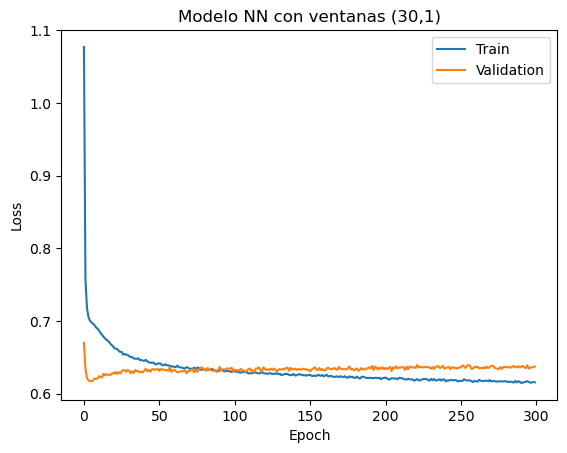

In [189]:
plt.plot(hist_NN_30_1.history['loss'])
plt.plot(hist_NN_30_1.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.title('Modelo NN con ventanas (30,1)')
plt.show()

In [190]:
# 1. El modelo predice en escala normalizada usando los datos de test
y_pred_nn_scaled_train_30_1 = model_NN_30_1.predict(X_train_flat_30_1)
y_pred_nn_scaled_val_30_1 = model_NN_30_1.predict(X_val_flat_30_1)
y_pred_nn_scaled_test_30_1 = model_NN_30_1.predict(X_test_flat_30_1)

# 2. Deshacemos la normalización usando el scaler de la llave (30,1)
scaler_y_30_1 = dicc_scaler[(30,1)]
y_pred_nn_real_train_30_1 = scaler_y_30_1.inverse_transform(y_pred_nn_scaled_train_30_1)
y_pred_nn_real_val_30_1 = scaler_y_30_1.inverse_transform(y_pred_nn_scaled_val_30_1)
y_pred_nn_real_test_30_1 = scaler_y_30_1.inverse_transform(y_pred_nn_scaled_test_30_1)

# 3. Comparamos las predicciones reales contra los datos originales sin normalizar
mae_nn_train_30_1 = mean_absolute_error(dicc_target_train_reg[(30,1)], y_pred_nn_real_train_30_1)
mae_nn_val_30_1 = mean_absolute_error(dicc_target_val[(30,1)], y_pred_nn_real_val_30_1)
mae_nn_test_30_1 = mean_absolute_error(dicc_target_test[(30,1)], y_pred_nn_real_test_30_1)

# 4. Comparamos manzanas con manzanas
print()
print('=======   Resultados modelo NN (30,1)   =======')
print()
print(f"MAE de la Regresión Lineal (train): {mae_reg_train[(30,1)]:.6f}")
print(f"MAE de la Red Neuronal (train):     {mae_nn_train_30_1:.6f}")
print()
print(f"MAE de la Regresión Lineal (val): {mae_reg_val[(30,1)]:.6f}")
print(f"MAE de la Red Neuronal (val):     {mae_nn_val_30_1:.6f}")
print()
print(f"MAE de la Regresión Lineal (test): {mae_reg_test[(30,1)]:.6f}")
print(f"MAE de la Red Neuronal (test):     {mae_nn_test_30_1:.6f}")
print()

341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

=======   Resultados modelo NN (30,1)   =======

MAE de la Regresión Lineal (train): 0.011731
MAE de la Red Neuronal (train):     0.010023

MAE de la Regresión Lineal (val): 0.010941
MAE de la Red Neuronal (val):     0.010705

MAE de la Regresión Lineal (test): 0.012992
MAE de la Red Neuronal (test):     0.012724



##### 3.1.3.2. Modelo con 5 datos de salida

In [185]:
train_data_30_5, train_target_30_5 = dicc_data_train_norm[(30,5)], dicc_target_train_norm[(30,5)]
val_data_30_5, val_target_30_5 = dicc_data_val_norm[(30,5)], dicc_target_val_norm[(30,5)]
test_data_30_5, test_target_30_5 = dicc_data_test_norm[(30,5)], dicc_target_test_norm[(30,5)]

In [186]:
num_samples_train_30_5 = train_data_30_5.shape[0]
num_samples_val_30_5 = val_data_30_5.shape[0]
num_samples_test_30_5 = test_data_30_5.shape[0]

# Flatten X_train_seq to (num_samples, input_window_size * num_features)
X_train_flat_30_5 = train_data_30_5.reshape(num_samples_train_30_5, -1)

# Flatten X_test_seq to (num_samples, input_window_size * num_features)
X_val_flat_30_5 = val_data_30_5.reshape(num_samples_val_30_5, -1)

# Flatten X_test_seq to (num_samples, input_window_size * num_features)
X_test_flat_30_5 = test_data_30_5.reshape(num_samples_test_30_5, -1)

In [191]:
# Modelo con 5 datos de entrada y uno de salida
model_NN_30_5 = Sequential()
model_NN_30_5.add(Dense(80, activation='relu', input_dim=(X_train_flat_30_5.shape[1])))
model_NN_30_5.add(Dropout(0.4))
model_NN_30_5.add(Dense(40, kernel_regularizer=regularizers.l2(0.001)))
#model_NN_30_5.add(Dense(64, activation='relu'))
model_NN_30_5.add(Dropout(0.2))

# 3. Capa de salida para los 23 activos (sin escalar, valores reales de retornos)
model_NN_30_5.add(Dense(train_target_30_5.shape[1], activation='linear'))

# DEFINICIÓN DE FUNCIÓN DE COSTE Y OPTIMIZADOR
model_NN_30_5.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

c:\Users\mateo\anaconda31\envs\trading\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [192]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_NN_30_5 = model_NN_30_5.fit(X_train_flat_30_5, train_target_30_5, validation_data=(X_val_flat_30_5, val_target_30_5), epochs=300)

Epoch 1/300
341/341 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 0.9386 - val_loss: 0.6410
Epoch 2/300
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.7603 - val_loss: 0.6278
Epoch 3/300
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.7400 - val_loss: 0.6226
Epoch 4/300
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.7299 - val_loss: 0.6175
Epoch 5/300
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.7204 - val_loss: 0.6160
Epoch 6/300
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.7150 - val_loss: 0.6153
Epoch 7/300
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.7075 - val_loss: 0.6182
Epoch 8/300
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.7019 - val_loss: 0.6163
Epoch 9/300
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.6958 - val_loss: 0.6215
Epoch 10/300
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.6899 - val_loss: 0.6270
Epoch 11/300
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.6857 - val_loss: 0.6237
Epoch 12/300
341/341 ━━━━━━━━━━━━━━━━━━━━

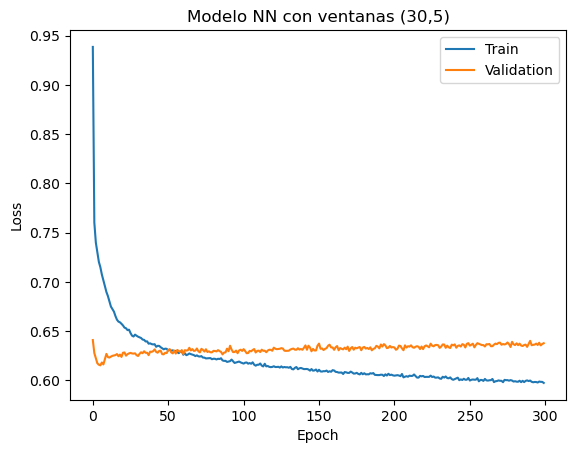

In [193]:
plt.plot(hist_NN_30_5.history['loss'])
plt.plot(hist_NN_30_5.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.title('Modelo NN con ventanas (30,5)')
plt.show()

In [194]:
# 1. El modelo predice en escala normalizada usando los datos de test
y_pred_nn_scaled_train_30_5 = model_NN_30_5.predict(X_train_flat_30_5)
y_pred_nn_scaled_val_30_5 = model_NN_30_5.predict(X_val_flat_30_5)
y_pred_nn_scaled_test_30_5 = model_NN_30_5.predict(X_test_flat_30_5)

# 2. Deshacemos la normalización usando el scaler de la llave (30,5)
scaler_y_30_5 = dicc_scaler[(30,5)]
y_pred_nn_real_train_30_5 = scaler_y_30_5.inverse_transform(y_pred_nn_scaled_train_30_5)
y_pred_nn_real_val_30_5 = scaler_y_30_5.inverse_transform(y_pred_nn_scaled_val_30_5)
y_pred_nn_real_test_30_5 = scaler_y_30_5.inverse_transform(y_pred_nn_scaled_test_30_5)

# 3. Comparamos las predicciones reales contra los datos originales sin normalizar
mae_nn_train_30_5 = mean_absolute_error(dicc_target_train_reg[(30,5)], y_pred_nn_real_train_30_5)
mae_nn_val_30_5 = mean_absolute_error(dicc_target_val[(30,5)], y_pred_nn_real_val_30_5)
mae_nn_test_30_5 = mean_absolute_error(dicc_target_test[(30,5)], y_pred_nn_real_test_30_5)

# 4. Comparamos manzanas con manzanas
print()
print('=======   Resultados modelo NN (30,5)   =======')
print()
print(f"MAE de la Regresión Lineal (train): {mae_reg_train[(30,5)]:.6f}")
print(f"MAE de la Red Neuronal (train):     {mae_nn_train_30_5:.6f}")
print()
print(f"MAE de la Regresión Lineal (val): {mae_reg_val[(30,5)]:.6f}")
print(f"MAE de la Red Neuronal (val):     {mae_nn_val_30_5:.6f}")
print()
print(f"MAE de la Regresión Lineal (test): {mae_reg_test[(30,5)]:.6f}")
print(f"MAE de la Red Neuronal (test):     {mae_nn_test_30_5:.6f}")
print()

341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

=======   Resultados modelo NN (30,5)   =======

MAE de la Regresión Lineal (train): 0.005402
MAE de la Red Neuronal (train):     0.004295

MAE de la Regresión Lineal (val): 0.004852
MAE de la Red Neuronal (val):     0.004822

MAE de la Regresión Lineal (test): 0.005921
MAE de la Red Neuronal (test):     0.005991



##### 3.1.3.3. Modelo con 30 datos de salida

In [195]:
train_data_30_30, train_target_30_30 = dicc_data_train_norm[(30,30)], dicc_target_train_norm[(30,30)]
val_data_30_30, val_target_30_30 = dicc_data_val_norm[(30,30)], dicc_target_val_norm[(30,30)]
test_data_30_30, test_target_30_30 = dicc_data_test_norm[(30,30)], dicc_target_test_norm[(30,30)]

In [196]:
num_samples_train_30_30 = train_data_30_30.shape[0]
num_samples_val_30_30 = val_data_30_30.shape[0]
num_samples_test_30_30 = test_data_30_30.shape[0]

# Flatten X_train_seq to (num_samples, input_window_size * num_features)
X_train_flat_30_30 = train_data_30_30.reshape(num_samples_train_30_30, -1)

# Flatten X_test_seq to (num_samples, input_window_size * num_features)
X_val_flat_30_30 = val_data_30_30.reshape(num_samples_val_30_30, -1)

# Flatten X_test_seq to (num_samples, input_window_size * num_features)
X_test_flat_30_30 = test_data_30_30.reshape(num_samples_test_30_30, -1)

In [203]:
# Modelo con 5 datos de entrada y uno de salida
model_NN_30_30 = Sequential()
model_NN_30_30.add(Dense(80, activation='relu', input_dim=(X_train_flat_30_30.shape[1])))
model_NN_30_30.add(Dropout(0.6))
model_NN_30_30.add(Dense(40, kernel_regularizer=regularizers.l2(0.003)))
#model_NN_30_30.add(Dense(64, activation='relu'))
model_NN_30_30.add(Dropout(0.3))

# 3. Capa de salida para los 23 activos (sin escalar, valores reales de retornos)
model_NN_30_30.add(Dense(train_target_30_30.shape[1], activation='linear'))

# DEFINICIÓN DE FUNCIÓN DE COSTE Y OPTIMIZADOR
model_NN_30_30.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

c:\Users\mateo\anaconda31\envs\trading\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [204]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_NN_30_30 = model_NN_30_30.fit(X_train_flat_30_30, train_target_30_30, validation_data=(X_val_flat_30_30, val_target_30_30), epochs=300)

Epoch 1/300
341/341 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 1.1177 - val_loss: 0.7042
Epoch 2/300
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.8103 - val_loss: 0.6686
Epoch 3/300
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.7720 - val_loss: 0.6549
Epoch 4/300
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.7587 - val_loss: 0.6505
Epoch 5/300
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.7531 - val_loss: 0.6486
Epoch 6/300
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.7498 - val_loss: 0.6487
Epoch 7/300
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.7469 - val_loss: 0.6496
Epoch 8/300
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.7444 - val_loss: 0.6488
Epoch 9/300
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.7400 - val_loss: 0.6495
Epoch 10/300
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.7376 - val_loss: 0.6494
Epoch 11/300
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.7359 - val_loss: 0.6508
Epoch 12/300
341/341 ━━━━━━━━━━━━━━━━━━━━

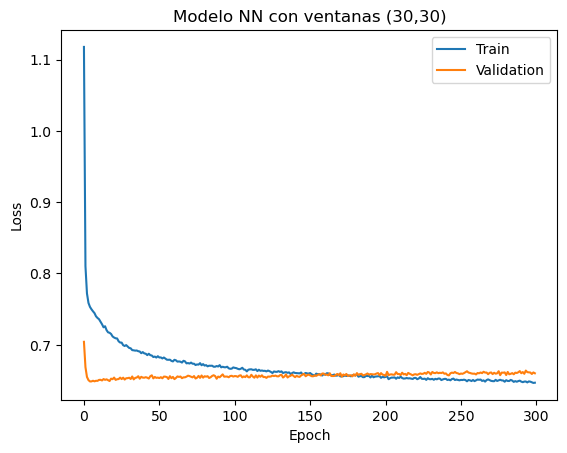

In [205]:
plt.plot(hist_NN_30_30.history['loss'])
plt.plot(hist_NN_30_30.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.title('Modelo NN con ventanas (30,30)')
plt.show()

In [206]:
# 1. El modelo predice en escala normalizada usando los datos de test
y_pred_nn_scaled_train_30_30 = model_NN_30_30.predict(X_train_flat_30_30)
y_pred_nn_scaled_val_30_30 = model_NN_30_30.predict(X_val_flat_30_30)
y_pred_nn_scaled_test_30_30 = model_NN_30_30.predict(X_test_flat_30_30)

# 2. Deshacemos la normalización usando el scaler de la llave (30,30)
scaler_y_30_30 = dicc_scaler[(30,30)]
y_pred_nn_real_train_30_30 = scaler_y_30_30.inverse_transform(y_pred_nn_scaled_train_30_30)
y_pred_nn_real_val_30_30 = scaler_y_30_30.inverse_transform(y_pred_nn_scaled_val_30_30)
y_pred_nn_real_test_30_30 = scaler_y_30_30.inverse_transform(y_pred_nn_scaled_test_30_30)

# 3. Comparamos las predicciones reales contra los datos originales sin normalizar
mae_nn_train_30_30 = mean_absolute_error(dicc_target_train_reg[(30,30)], y_pred_nn_real_train_30_30)
mae_nn_val_30_30 = mean_absolute_error(dicc_target_val[(30,30)], y_pred_nn_real_val_30_30)
mae_nn_test_30_30 = mean_absolute_error(dicc_target_test[(30,30)], y_pred_nn_real_test_30_30)

# 4. Comparamos manzanas con manzanas
print()
print('=======   Resultados modelo mixto (30,30)   =======')
print()
print(f"MAE de la Regresión Lineal (train): {mae_reg_train[(30,30)]:.6f}")
print(f"MAE de la Red Neuronal (train):     {mae_nn_train_30_30:.6f}")
print()
print(f"MAE de la Regresión Lineal (val): {mae_reg_val[(30,30)]:.6f}")
print(f"MAE de la Red Neuronal (val):     {mae_nn_val_30_30:.6f}")
print()
print(f"MAE de la Regresión Lineal (test): {mae_reg_test[(30,30)]:.6f}")
print(f"MAE de la Red Neuronal (test):     {mae_nn_test_30_30:.6f}")
print()

341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

=======   Resultados modelo mixto (30,30)   =======

MAE de la Regresión Lineal (train): 0.002170
MAE de la Red Neuronal (train):     0.001790

MAE de la Regresión Lineal (val): 0.001950
MAE de la Red Neuronal (val):     0.001921

MAE de la Regresión Lineal (test): 0.002442
MAE de la Red Neuronal (test):     0.002428



##### 3.1.3.4. Modelo con 90 datos de salida

In [207]:
train_data_30_90, train_target_30_90 = dicc_data_train_norm[(30,90)], dicc_target_train_norm[(30,90)]
val_data_30_90, val_target_30_90 = dicc_data_val_norm[(30,90)], dicc_target_val_norm[(30,90)]
test_data_30_90, test_target_30_90 = dicc_data_test_norm[(30,90)], dicc_target_test_norm[(30,90)]

In [208]:
num_samples_train_30_90 = train_data_30_90.shape[0]
num_samples_val_30_90 = val_data_30_90.shape[0]
num_samples_test_30_90 = test_data_30_90.shape[0]

# Flatten X_train_seq to (num_samples, input_window_size * num_features)
X_train_flat_30_90 = train_data_30_90.reshape(num_samples_train_30_90, -1)

# Flatten X_test_seq to (num_samples, input_window_size * num_features)
X_val_flat_30_90 = val_data_30_90.reshape(num_samples_val_30_90, -1)

# Flatten X_test_seq to (num_samples, input_window_size * num_features)
X_test_flat_30_90 = test_data_30_90.reshape(num_samples_test_30_90, -1)

In [220]:
# Modelo con 5 datos de entrada y uno de salida
model_NN_30_90 = Sequential()
model_NN_30_90.add(Dense(80, activation='relu', input_dim=(X_train_flat_30_90.shape[1])))
model_NN_30_90.add(Dropout(0.6))
model_NN_30_90.add(Dense(40, activation='relu', kernel_regularizer=regularizers.l2(0.001)))
#model_NN_30_90.add(Dense(64, activation='relu'))
model_NN_30_90.add(Dropout(0.4))

# 3. Capa de salida para los 23 activos (sin escalar, valores reales de retornos)
model_NN_30_90.add(Dense(train_target_30_90.shape[1], activation='linear'))

# DEFINICIÓN DE FUNCIÓN DE COSTE Y OPTIMIZADOR
model_NN_30_90.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

In [221]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_NN_30_90 = model_NN_30_90.fit(X_train_flat_30_90, train_target_30_90, validation_data=(X_val_flat_30_90, val_target_30_90), epochs=300)

Epoch 1/300
339/339 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.9101 - val_loss: 0.7020
Epoch 2/300
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.7979 - val_loss: 0.6870
Epoch 3/300
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.7818 - val_loss: 0.6758
Epoch 4/300
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.7721 - val_loss: 0.6688
Epoch 5/300
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.7667 - val_loss: 0.6652
Epoch 6/300
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.7641 - val_loss: 0.6635
Epoch 7/300
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.7629 - val_loss: 0.6631
Epoch 8/300
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.7625 - val_loss: 0.6632
Epoch 9/300
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.7620 - val_loss: 0.6635
Epoch 10/300
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.7617 - val_loss: 0.6641
Epoch 11/300
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.7613 - val_loss: 0.6644
Epoch 12/300
339/339 ━━━━━━━━━━━━━━━━━━━━

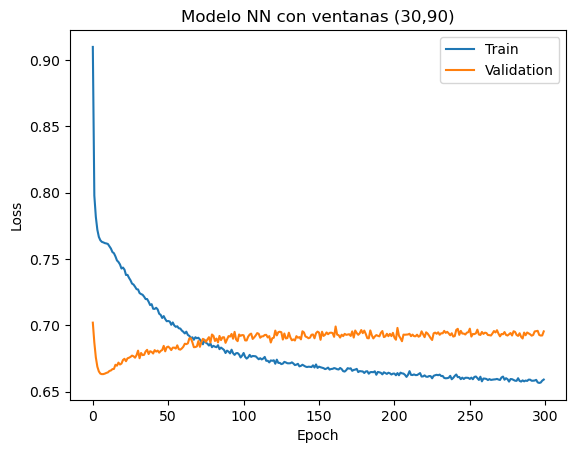

In [222]:
plt.plot(hist_NN_30_90.history['loss'])
plt.plot(hist_NN_30_90.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.title('Modelo NN con ventanas (30,90)')
plt.show()

In [223]:
# 1. El modelo predice en escala normalizada usando los datos de test
y_pred_nn_scaled_train_30_90 = model_NN_30_90.predict(X_train_flat_30_90)
y_pred_nn_scaled_val_30_90 = model_NN_30_90.predict(X_val_flat_30_90)
y_pred_nn_scaled_test_30_90 = model_NN_30_90.predict(X_test_flat_30_90)

# 2. Deshacemos la normalización usando el scaler de la llave (30,90)
scaler_y_30_90 = dicc_scaler[(30,90)]
y_pred_nn_real_train_30_90 = scaler_y_30_90.inverse_transform(y_pred_nn_scaled_train_30_90)
y_pred_nn_real_val_30_90 = scaler_y_30_90.inverse_transform(y_pred_nn_scaled_val_30_90)
y_pred_nn_real_test_30_90 = scaler_y_30_90.inverse_transform(y_pred_nn_scaled_test_30_90)

# 3. Comparamos las predicciones reales contra los datos originales sin normalizar
mae_nn_train_30_90 = mean_absolute_error(dicc_target_train_reg[(30,90)], y_pred_nn_real_train_30_90)
mae_nn_val_30_90 = mean_absolute_error(dicc_target_val[(30,90)], y_pred_nn_real_val_30_90)
mae_nn_test_30_90 = mean_absolute_error(dicc_target_test[(30,90)], y_pred_nn_real_test_30_90)

# 4. Comparamos manzanas con manzanas
print()
print('=======   Resultados modelo NN (30,90)   =======')
print()
print(f"MAE de la Regresión Lineal (train): {mae_reg_train[(30,90)]:.6f}")
print(f"MAE de la Red Neuronal (train):     {mae_nn_train_30_90:.6f}")
print()
print(f"MAE de la Regresión Lineal (val): {mae_reg_val[(30,90)]:.6f}")
print(f"MAE de la Red Neuronal (val):     {mae_nn_val_30_90:.6f}")
print()
print(f"MAE de la Regresión Lineal (test): {mae_reg_test[(30,90)]:.6f}")
print(f"MAE de la Red Neuronal (test):     {mae_nn_test_30_90:.6f}")
print()

339/339 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

=======   Resultados modelo NN (30,90)   =======

MAE de la Regresión Lineal (train): 0.001241
MAE de la Red Neuronal (train):     0.001035

MAE de la Regresión Lineal (val): 0.001132
MAE de la Red Neuronal (val):     0.001136

MAE de la Regresión Lineal (test): 0.001353
MAE de la Red Neuronal (test):     0.001302



#### 3.1.4 Modelos con 90 datos de entrada

En el caso de los modelos con una ventana de entrada de 90 días, podemos apreciar que las curvas del error converjen. Son los modelos que dan mejores resultados en validación y test. Son los modelos más robustos

##### 3.1.4.1. Modelo con 1 dato de salida

In [224]:
train_data_90_1, train_target_90_1 = dicc_data_train_norm[(90,1)], dicc_target_train_norm[(90,1)]
val_data_90_1, val_target_90_1 = dicc_data_val_norm[(90,1)], dicc_target_val_norm[(90,1)]
test_data_90_1, test_target_90_1 = dicc_data_test_norm[(90,1)], dicc_target_test_norm[(90,1)]

In [225]:
num_samples_train_90_1 = train_data_90_1.shape[0]
num_samples_val_90_1 = val_data_90_1.shape[0]
num_samples_test_90_1 = test_data_90_1.shape[0]

# Flatten X_train_seq to (num_samples, input_window_size * num_features)
X_train_flat_90_1 = train_data_90_1.reshape(num_samples_train_90_1, -1)

# Flatten X_test_seq to (num_samples, input_window_size * num_features)
X_val_flat_90_1 = val_data_90_1.reshape(num_samples_val_90_1, -1)

# Flatten X_test_seq to (num_samples, input_window_size * num_features)
X_test_flat_90_1 = test_data_90_1.reshape(num_samples_test_90_1, -1)

In [236]:
# Modelo con 5 datos de entrada y uno de salida
model_NN_90_1 = Sequential()
model_NN_90_1.add(Dense(80, activation='relu', input_dim=(X_train_flat_90_1.shape[1])))
model_NN_90_1.add(Dropout(0.4))
#model_NN_90_1.add(Dense(40, kernel_regularizer=regularizers.l2(0.003)))
model_NN_90_1.add(Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.003)))
model_NN_90_1.add(Dropout(0.2))

# 3. Capa de salida para los 23 activos (sin escalar, valores reales de retornos)
model_NN_90_1.add(Dense(train_target_90_1.shape[1], activation='linear'))

# DEFINICIÓN DE FUNCIÓN DE COSTE Y OPTIMIZADOR
model_NN_90_1.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

c:\Users\mateo\anaconda31\envs\trading\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [237]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_NN_90_1 = model_NN_90_1.fit(X_train_flat_90_1, train_target_90_1, validation_data=(X_val_flat_90_1, val_target_90_1), epochs=300)

Epoch 1/300
340/340 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.8863 - val_loss: 0.6722
Epoch 2/300
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.7286 - val_loss: 0.6235
Epoch 3/300
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.7037 - val_loss: 0.6157
Epoch 4/300
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.7001 - val_loss: 0.6151
Epoch 5/300
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.6978 - val_loss: 0.6168
Epoch 6/300
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.6941 - val_loss: 0.6186
Epoch 7/300
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.6885 - val_loss: 0.6177
Epoch 8/300
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.6836 - val_loss: 0.6230
Epoch 9/300
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.6777 - val_loss: 0.6223
Epoch 10/300
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.6723 - val_loss: 0.6237
Epoch 11/300
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.6677 - val_loss: 0.6269
Epoch 12/300
340/340 ━━━━━━━━━━━━━━━━━━━━

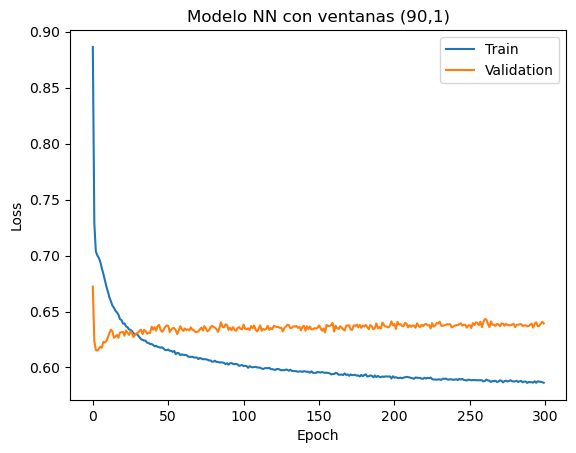

In [240]:
plt.plot(hist_NN_90_1.history['loss'])
plt.plot(hist_NN_90_1.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.title('Modelo NN con ventanas (90,1)')
plt.show()

In [241]:
# 1. El modelo predice en escala normalizada usando los datos de test
y_pred_nn_scaled_train_90_1 = model_NN_90_1.predict(X_train_flat_90_1)
y_pred_nn_scaled_val_90_1 = model_NN_90_1.predict(X_val_flat_90_1)
y_pred_nn_scaled_test_90_1 = model_NN_90_1.predict(X_test_flat_90_1)

# 2. Deshacemos la normalización usando el scaler de la llave (90,1)
scaler_y_90_1 = dicc_scaler[(90,1)]
y_pred_nn_real_train_90_1 = scaler_y_90_1.inverse_transform(y_pred_nn_scaled_train_90_1)
y_pred_nn_real_val_90_1 = scaler_y_90_1.inverse_transform(y_pred_nn_scaled_val_90_1)
y_pred_nn_real_test_90_1 = scaler_y_90_1.inverse_transform(y_pred_nn_scaled_test_90_1)

# 3. Comparamos las predicciones reales contra los datos originales sin normalizar
mae_nn_train_90_1 = mean_absolute_error(dicc_target_train_reg[(90,1)], y_pred_nn_real_train_90_1)
mae_nn_val_90_1 = mean_absolute_error(dicc_target_val[(90,1)], y_pred_nn_real_val_90_1)
mae_nn_test_90_1 = mean_absolute_error(dicc_target_test[(90,1)], y_pred_nn_real_test_90_1)

# 4. Comparamos manzanas con manzanas
print()
print('=======   Resultados modelo NN (90,1)   =======')
print()
print(f"MAE de la Regresión Lineal (train): {mae_reg_train[(90,1)]:.6f}")
print(f"MAE de la Red Neuronal (train):     {mae_nn_train_90_1:.6f}")
print()
print(f"MAE de la Regresión Lineal (val): {mae_reg_val[(90,1)]:.6f}")
print(f"MAE de la Red Neuronal (val):     {mae_nn_val_90_1:.6f}")
print()
print(f"MAE de la Regresión Lineal (test): {mae_reg_test[(90,1)]:.6f}")
print(f"MAE de la Red Neuronal (test):     {mae_nn_test_90_1:.6f}")
print()

340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

=======   Resultados modelo NN (90,1)   =======

MAE de la Regresión Lineal (train): 0.011095
MAE de la Red Neuronal (train):     0.009625

MAE de la Regresión Lineal (val): 0.012049
MAE de la Red Neuronal (val):     0.010770

MAE de la Regresión Lineal (test): 0.014414
MAE de la Red Neuronal (test):     0.012695



##### 3.1.4.2. Modelo con 5 datos de salida

In [230]:
train_data_90_5, train_target_90_5 = dicc_data_train_norm[(90,5)], dicc_target_train_norm[(90,5)]
val_data_90_5, val_target_90_5 = dicc_data_val_norm[(90,5)], dicc_target_val_norm[(90,5)]
test_data_90_5, test_target_90_5 = dicc_data_test_norm[(90,5)], dicc_target_test_norm[(90,5)]

In [231]:
num_samples_train_90_5 = train_data_90_5.shape[0]
num_samples_val_90_5 = val_data_90_5.shape[0]
num_samples_test_90_5 = test_data_90_5.shape[0]

# Flatten X_train_seq to (num_samples, input_window_size * num_features)
X_train_flat_90_5 = train_data_90_5.reshape(num_samples_train_90_5, -1)

# Flatten X_test_seq to (num_samples, input_window_size * num_features)
X_val_flat_90_5 = val_data_90_5.reshape(num_samples_val_90_5, -1)

# Flatten X_test_seq to (num_samples, input_window_size * num_features)
X_test_flat_90_5 = test_data_90_5.reshape(num_samples_test_90_5, -1)

In [247]:
# Modelo con 5 datos de entrada y uno de salida
model_NN_90_5 = Sequential()
model_NN_90_5.add(Dense(80, activation='relu', input_dim=(X_train_flat_90_5.shape[1])))
model_NN_90_5.add(Dropout(0.5))
model_NN_90_5.add(Dense(40, activation='relu', kernel_regularizer=regularizers.l2(0.003)))
#model_NN_90_5.add(Dense(64, activation='relu'))
model_NN_90_5.add(Dropout(0.4))

# 3. Capa de salida para los 23 activos (sin escalar, valores reales de retornos)
model_NN_90_5.add(Dense(train_target_90_5.shape[1], activation='linear'))

# DEFINICIÓN DE FUNCIÓN DE COSTE Y OPTIMIZADOR
model_NN_90_5.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

c:\Users\mateo\anaconda31\envs\trading\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [248]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_NN_90_5 = model_NN_90_5.fit(X_train_flat_90_5, train_target_90_5, validation_data=(X_val_flat_90_5, val_target_90_5), epochs=300)

Epoch 1/300
340/340 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.9284 - val_loss: 0.6821
Epoch 2/300
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.7695 - val_loss: 0.6314
Epoch 3/300
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.7367 - val_loss: 0.6159
Epoch 4/300
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.7281 - val_loss: 0.6128
Epoch 5/300
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.7261 - val_loss: 0.6126
Epoch 6/300
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.7250 - val_loss: 0.6126
Epoch 7/300
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.7233 - val_loss: 0.6126
Epoch 8/300
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.7206 - val_loss: 0.6144
Epoch 9/300
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.7177 - val_loss: 0.6143
Epoch 10/300
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.7134 - val_loss: 0.6138
Epoch 11/300
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.7092 - val_loss: 0.6169
Epoch 12/300
340/340 ━━━━━━━━━━━━━━━━━━━━

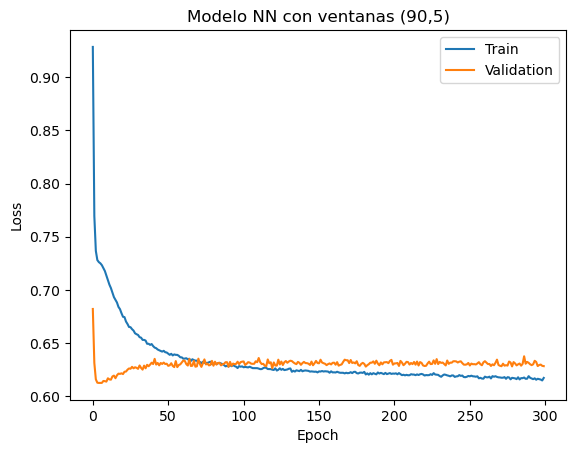

In [249]:
plt.plot(hist_NN_90_5.history['loss'])
plt.plot(hist_NN_90_5.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.title('Modelo NN con ventanas (90,5)')
plt.show()

In [250]:
# 1. El modelo predice en escala normalizada usando los datos de test
y_pred_nn_scaled_train_90_5 = model_NN_90_5.predict(X_train_flat_90_5)
y_pred_nn_scaled_val_90_5 = model_NN_90_5.predict(X_val_flat_90_5)
y_pred_nn_scaled_test_90_5 = model_NN_90_5.predict(X_test_flat_90_5)

# 2. Deshacemos la normalización usando el scaler de la llave (90,5)
scaler_y_90_5 = dicc_scaler[(90,5)]
y_pred_nn_real_train_90_5 = scaler_y_90_5.inverse_transform(y_pred_nn_scaled_train_90_5)
y_pred_nn_real_val_90_5 = scaler_y_90_5.inverse_transform(y_pred_nn_scaled_val_90_5)
y_pred_nn_real_test_90_5 = scaler_y_90_5.inverse_transform(y_pred_nn_scaled_test_90_5)

# 3. Comparamos las predicciones reales contra los datos originales sin normalizar
mae_nn_train_90_5 = mean_absolute_error(dicc_target_train_reg[(90,5)], y_pred_nn_real_train_90_5)
mae_nn_val_90_5 = mean_absolute_error(dicc_target_val[(90,5)], y_pred_nn_real_val_90_5)
mae_nn_test_90_5 = mean_absolute_error(dicc_target_test[(90,5)], y_pred_nn_real_test_90_5)

# 4. Comparamos manzanas con manzanas
print()
print('=======   Resultados modelo NN (90,5)   =======')
print()
print(f"MAE de la Regresión Lineal (train): {mae_reg_train[(90,5)]:.6f}")
print(f"MAE de la Red Neuronal (train):     {mae_nn_train_90_5:.6f}")
print()
print(f"MAE de la Regresión Lineal (val): {mae_reg_val[(90,5)]:.6f}")
print(f"MAE de la Red Neuronal (val):     {mae_nn_val_90_5:.6f}")
print()
print(f"MAE de la Regresión Lineal (test): {mae_reg_test[(90,5)]:.6f}")
print(f"MAE de la Red Neuronal (test):     {mae_nn_test_90_5:.6f}")
print()

340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

=======   Resultados modelo NN (90,5)   =======

MAE de la Regresión Lineal (train): 0.005093
MAE de la Red Neuronal (train):     0.004546

MAE de la Regresión Lineal (val): 0.005364
MAE de la Red Neuronal (val):     0.004761

MAE de la Regresión Lineal (test): 0.006518
MAE de la Red Neuronal (test):     0.005690



##### 3.1.4.3. Modelo con 30 datos de salida

In [232]:
train_data_90_30, train_target_90_30 = dicc_data_train_norm[(90,30)], dicc_target_train_norm[(90,30)]
val_data_90_30, val_target_90_30 = dicc_data_val_norm[(90,30)], dicc_target_val_norm[(90,30)]
test_data_90_30, test_target_90_30 = dicc_data_test_norm[(90,30)], dicc_target_test_norm[(90,30)]

In [233]:
num_samples_train_90_30 = train_data_90_30.shape[0]
num_samples_val_90_30 = val_data_90_30.shape[0]
num_samples_test_90_30 = test_data_90_30.shape[0]

# Flatten X_train_seq to (num_samples, input_window_size * num_features)
X_train_flat_90_30 = train_data_90_30.reshape(num_samples_train_90_30, -1)

# Flatten X_test_seq to (num_samples, input_window_size * num_features)
X_val_flat_90_30 = val_data_90_30.reshape(num_samples_val_90_30, -1)

# Flatten X_test_seq to (num_samples, input_window_size * num_features)
X_test_flat_90_30 = test_data_90_30.reshape(num_samples_test_90_30, -1)

In [256]:
# Modelo con 5 datos de entrada y uno de salida
model_NN_90_30 = Sequential()
model_NN_90_30.add(Dense(80, activation='relu', input_dim=(X_train_flat_90_30.shape[1])))
model_NN_90_30.add(Dropout(0.5))
model_NN_90_30.add(Dense(40, activation='relu', kernel_regularizer=regularizers.l2(0.005)))
#model_NN_90_30.add(Dense(64, activation='relu'))
model_NN_90_30.add(Dropout(0.4))

# 3. Capa de salida para los 23 activos (sin escalar, valores reales de retornos)
model_NN_90_30.add(Dense(train_target_90_30.shape[1], activation='linear'))

# DEFINICIÓN DE FUNCIÓN DE COSTE Y OPTIMIZADOR
model_NN_90_30.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

In [257]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_NN_90_30 = model_NN_90_30.fit(X_train_flat_90_30, train_target_90_30, validation_data=(X_val_flat_90_30, val_target_90_30), epochs=300)

Epoch 1/300
339/339 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.9870 - val_loss: 0.7232
Epoch 2/300
339/339 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.7894 - val_loss: 0.6618
Epoch 3/300
339/339 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.7591 - val_loss: 0.6528
Epoch 4/300
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.7552 - val_loss: 0.6510
Epoch 5/300
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.7539 - val_loss: 0.6515
Epoch 6/300
339/339 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.7526 - val_loss: 0.6521
Epoch 7/300
339/339 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.7484 - val_loss: 0.6550
Epoch 8/300
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.7441 - val_loss: 0.6566
Epoch 9/300
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.7391 - val_loss: 0.6572
Epoch 10/300
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.7341 - val_loss: 0.6602
Epoch 11/300
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.7301 - val_loss: 0.6624
Epoch 12/300
339/339 ━━━━━━━━━━━━━━━━━━━━

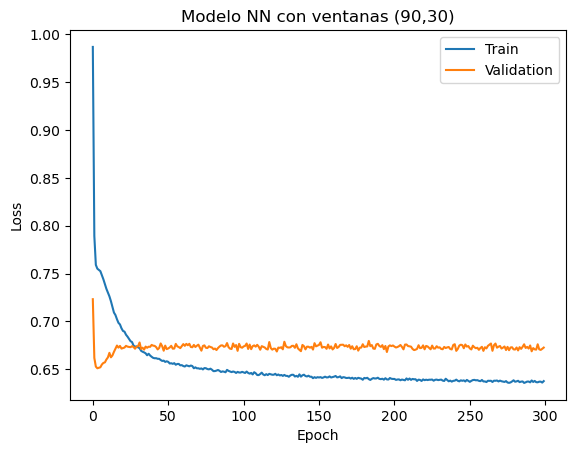

In [258]:
plt.plot(hist_NN_90_30.history['loss'])
plt.plot(hist_NN_90_30.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.title('Modelo NN con ventanas (90,30)')
plt.show()

In [259]:
# 1. El modelo predice en escala normalizada usando los datos de test
y_pred_nn_scaled_train_90_30 = model_NN_90_30.predict(X_train_flat_90_30)
y_pred_nn_scaled_val_90_30 = model_NN_90_30.predict(X_val_flat_90_30)
y_pred_nn_scaled_test_90_30 = model_NN_90_30.predict(X_test_flat_90_30)

# 2. Deshacemos la normalización usando el scaler de la llave (90,30)
scaler_y_90_30 = dicc_scaler[(90,30)]
y_pred_nn_real_train_90_30 = scaler_y_90_30.inverse_transform(y_pred_nn_scaled_train_90_30)
y_pred_nn_real_val_90_30 = scaler_y_90_30.inverse_transform(y_pred_nn_scaled_val_90_30)
y_pred_nn_real_test_90_30 = scaler_y_90_30.inverse_transform(y_pred_nn_scaled_test_90_30)

# 3. Comparamos las predicciones reales contra los datos originales sin normalizar
mae_nn_train_90_30 = mean_absolute_error(dicc_target_train_reg[(90,30)], y_pred_nn_real_train_90_30)
mae_nn_val_90_30 = mean_absolute_error(dicc_target_val[(90,30)], y_pred_nn_real_val_90_30)
mae_nn_test_90_30 = mean_absolute_error(dicc_target_test[(90,30)], y_pred_nn_real_test_90_30)

# 4. Comparamos manzanas con manzanas
print()
print('=======   Resultados modelo NN (90,30)   =======')
print()
print(f"MAE de la Regresión Lineal (train): {mae_reg_train[(90,30)]:.6f}")
print(f"MAE de la Red Neuronal (train):     {mae_nn_train_90_30:.6f}")
print()
print(f"MAE de la Regresión Lineal (val): {mae_reg_val[(90,30)]:.6f}")
print(f"MAE de la Red Neuronal (val):     {mae_nn_val_90_30:.6f}")
print()
print(f"MAE de la Regresión Lineal (test): {mae_reg_test[(90,30)]:.6f}")
print(f"MAE de la Red Neuronal (test):     {mae_nn_test_90_30:.6f}")
print()

339/339 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

=======   Resultados modelo NN (90,30)   =======

MAE de la Regresión Lineal (train): 0.002013
MAE de la Red Neuronal (train):     0.001794

MAE de la Regresión Lineal (val): 0.002168
MAE de la Red Neuronal (val):     0.001956

MAE de la Regresión Lineal (test): 0.002699
MAE de la Red Neuronal (test):     0.002358



##### 3.1.4.4. Modelo con 90 datos de salida

In [234]:
train_data_90_90, train_target_90_90 = dicc_data_train_norm[(90,90)], dicc_target_train_norm[(90,90)]
val_data_90_90, val_target_90_90 = dicc_data_val_norm[(90,90)], dicc_target_val_norm[(90,90)]
test_data_90_90, test_target_90_90 = dicc_data_test_norm[(90,90)], dicc_target_test_norm[(90,90)]

In [235]:
num_samples_train_90_90 = train_data_90_90.shape[0]
num_samples_val_90_90 = val_data_90_90.shape[0]
num_samples_test_90_90 = test_data_90_90.shape[0]

# Flatten X_train_seq to (num_samples, input_window_size * num_features)
X_train_flat_90_90 = train_data_90_90.reshape(num_samples_train_90_90, -1)

# Flatten X_test_seq to (num_samples, input_window_size * num_features)
X_val_flat_90_90 = val_data_90_90.reshape(num_samples_val_90_90, -1)

# Flatten X_test_seq to (num_samples, input_window_size * num_features)
X_test_flat_90_90 = test_data_90_90.reshape(num_samples_test_90_90, -1)

In [266]:
# Modelo con 5 datos de entrada y uno de salida
model_NN_90_90 = Sequential()
model_NN_90_90.add(Dense(100, activation='relu', input_dim=(X_train_flat_90_90.shape[1])))
model_NN_90_90.add(Dropout(0.5))
model_NN_90_90.add(Dense(50, activation='relu', kernel_regularizer=regularizers.l2(0.007)))
#model_NN_90_90.add(Dense(64, activation='relu'))
model_NN_90_90.add(Dropout(0.4))
model_NN_90_90.add(Dense(40, activation='relu'))
model_NN_90_90.add(Dropout(0.4))

# 3. Capa de salida para los 23 activos (sin escalar, valores reales de retornos)
model_NN_90_90.add(Dense(train_target_90_90.shape[1], activation='linear'))

# DEFINICIÓN DE FUNCIÓN DE COSTE Y OPTIMIZADOR
model_NN_90_90.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

c:\Users\mateo\anaconda31\envs\trading\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [267]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_NN_90_90 = model_NN_90_90.fit(X_train_flat_90_90, train_target_90_90, validation_data=(X_val_flat_90_90, val_target_90_90), epochs=300)

Epoch 1/300
338/338 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 1.0405 - val_loss: 0.7344
Epoch 2/300
338/338 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.7887 - val_loss: 0.6720
Epoch 3/300
338/338 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.7641 - val_loss: 0.6670
Epoch 4/300
338/338 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.7620 - val_loss: 0.6665
Epoch 5/300
338/338 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.7616 - val_loss: 0.6664
Epoch 6/300
338/338 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.7613 - val_loss: 0.6669
Epoch 7/300
338/338 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.7608 - val_loss: 0.6670
Epoch 8/300
338/338 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.7603 - val_loss: 0.6671
Epoch 9/300
338/338 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.7588 - val_loss: 0.6676
Epoch 10/300
338/338 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.7562 - val_loss: 0.6687
Epoch 11/300
338/338 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.7537 - val_loss: 0.6683
Epoch 12/300
338/338 ━━━━━━━━━━━━━━━━━━━━

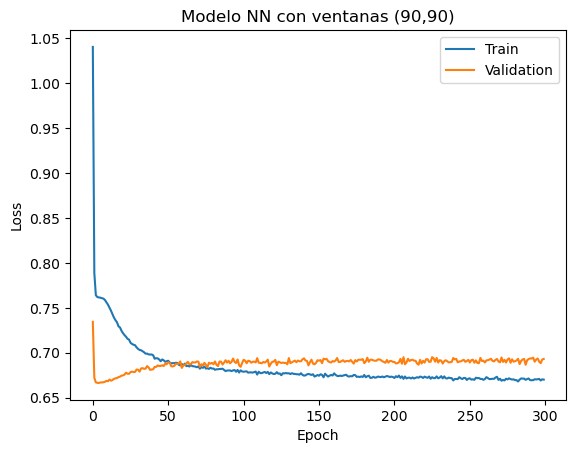

In [268]:
plt.plot(hist_NN_90_90.history['loss'])
plt.plot(hist_NN_90_90.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.title('Modelo NN con ventanas (90,90)')
plt.show()

In [269]:
# 1. El modelo predice en escala normalizada usando los datos de test
y_pred_nn_scaled_train_90_90 = model_NN_90_90.predict(X_train_flat_90_90)
y_pred_nn_scaled_val_90_90 = model_NN_90_90.predict(X_val_flat_90_90)
y_pred_nn_scaled_test_90_90 = model_NN_90_90.predict(X_test_flat_90_90)

# 2. Deshacemos la normalización usando el scaler de la llave (90,90)
scaler_y_90_90 = dicc_scaler[(90,90)]
y_pred_nn_real_train_90_90 = scaler_y_90_90.inverse_transform(y_pred_nn_scaled_train_90_90)
y_pred_nn_real_val_90_90 = scaler_y_90_90.inverse_transform(y_pred_nn_scaled_val_90_90)
y_pred_nn_real_test_90_90 = scaler_y_90_90.inverse_transform(y_pred_nn_scaled_test_90_90)

# 3. Comparamos las predicciones reales contra los datos originales sin normalizar
mae_nn_train_90_90 = mean_absolute_error(dicc_target_train_reg[(90,90)], y_pred_nn_real_train_90_90)
mae_nn_val_90_90 = mean_absolute_error(dicc_target_val[(90,90)], y_pred_nn_real_val_90_90)
mae_nn_test_90_90 = mean_absolute_error(dicc_target_test[(90,90)], y_pred_nn_real_test_90_90)

# 4. Comparamos manzanas con manzanas
print()
print('=======   Resultados modelo NN (90,90)   =======')
print()
print(f"MAE de la Regresión Lineal (train): {mae_reg_train[(90,90)]:.6f}")
print(f"MAE de la Red Neuronal (train):     {mae_nn_train_90_90:.6f}")
print()
print(f"MAE de la Regresión Lineal (val): {mae_reg_val[(90,90)]:.6f}")
print(f"MAE de la Red Neuronal (val):     {mae_nn_val_90_90:.6f}")
print()
print(f"MAE de la Regresión Lineal (test): {mae_reg_test[(90,90)]:.6f}")
print(f"MAE de la Red Neuronal (test):     {mae_nn_test_90_90:.6f}")
print()

338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

=======   Resultados modelo NN (90,90)   =======

MAE de la Regresión Lineal (train): 0.001143
MAE de la Red Neuronal (train):     0.001151

MAE de la Regresión Lineal (val): 0.001239
MAE de la Red Neuronal (val):     0.001131

MAE de la Regresión Lineal (test): 0.001551
MAE de la Red Neuronal (test):     0.001310



## 4. Conclusiones

En el caso de las capas densas, los vectores de entrada hay que interpretarlos como las "variables" que utilizamos para predecir el target. **A medida que este vector de entrada es más grande la capacidad de la red en cuanto a robustez y predicción mejora** respecto al baseline (regresión lineal). 

Los modelos han constado de la capa de entrada, una o dos capas ocultas, según la combinación de ventanas de entrada y salida, y una capa de salida con las predicciones de los retornos para cada uno de los 23 activos financieros